# Finite State Projection Algorithm (FSP)

In [1]:
from dataclasses import dataclass
from pathlib import Path
import math
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import expm_multiply

## Parameters in the examples

This section contains all parameters that differ among the nine examples.


In [2]:
@dataclass(frozen=True)
class FSPConfig:
    """
    Parameters for finite-state-projection experiments.

    Parameters
    ----------
    name:
        Experiment identifier.
    D0_offdiag:
        Off-diagonal elements for the transition rate matrix D_0.
    D1:
        Rate matrix for the transition rate matrix D_1 (of size one).
    r_max:
        Largest explicitly represented burst size.
    lam:
        Parameter in the geometric distribution.
        ``D_r = lam**(r - 1) * D1``.
    delta:
        Protein degradation rate.
    t_final:
        Time at which the probability distribution is evaluated.
    output_file:
        File used to save the marginal protein distribution.
    description:
        Human-readable description of the experiment.
    """

    name: str
    D0_offdiag: np.ndarray
    D1: np.ndarray
    r_max: int
    lam: float
    delta: float
    t_final: float
    output_file: str
    description: str = ""

EXPERIMENTS: dict[str, FSPConfig] = {
    # -----------------------------------------------------------------------
    # FSP1
    # -----------------------------------------------------------------------
    "FSP1": FSPConfig(
        name="FSP1",
        D0_offdiag=np.array(
            [
                [0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0],
            ],
            dtype=float,
        ),
        D1=np.array(
            [
                [1.0, 1.0, 1.0],
                [1.0, 5.0, 1.0],
                [1.0, 1.0, 5.0],
            ],
            dtype=float,
        ),
        r_max=20,
        lam=0.1,
        delta=1.0,
        t_final=50.0,
        output_file="FSP1.npy",
        description="Three-state model with lambda=0.1.",
    ),

    # -----------------------------------------------------------------------
    # FSP2
    # -----------------------------------------------------------------------
    "FSP2": FSPConfig(
        name="FSP2",
        D0_offdiag=np.array(
            [
                [0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0],
            ],
            dtype=float,
        ),
        D1=np.array(
            [
                [1.0, 1.0, 1.0],
                [1.0, 5.0, 1.0],
                [1.0, 1.0, 5.0],
            ],
            dtype=float,
        ),
        r_max=20,
        lam=0.2,
        delta=1.0,
        t_final=50.0,
        output_file="FSP2.npy",
        description="Same matrices as FSP1, with lambda=0.2.",
    ),

    # -----------------------------------------------------------------------
    # FSP3
    # -----------------------------------------------------------------------
    "FSP3": FSPConfig(
        name="FSP3",
        D0_offdiag=np.array(
            [
                [0.0, 0.05],
                [0.2, 0.0],
            ],
            dtype=float,
        ),
        D1=np.array(
            [
                [0.0, 0.0],
                [0.0, 2.0],
            ],
            dtype=float,
        ),
        r_max=20,
        lam=0.3,
        delta=1.0,
        t_final=50.0,
        output_file="FSP3.npy",
        description="Two-state model with slow asymmetric switching.",
    ),

    # -----------------------------------------------------------------------
    # FSP4
    # -----------------------------------------------------------------------
    "FSP4": FSPConfig(
        name="FSP4",
        D0_offdiag=np.array(
            [
                [0.0, 4.0],
                [6.0, 0.0],
            ],
            dtype=float,
        ),
        D1=np.array(
            [
                [0.0, 0.0],
                [0.0, 2.0],
            ],
            dtype=float,
        ),
        r_max=20,
        lam=0.3,
        delta=1.0,
        t_final=50.0,
        output_file="FSP4.npy",
        description="Same burst structure as FSP3, with faster switching.",
    ),

    # -----------------------------------------------------------------------
    # FSP5
    # -----------------------------------------------------------------------
    "FSP5": FSPConfig(
        name="FSP5",
        D0_offdiag=np.array(
            [
                [0.0, 0.030, 0.0, 0.0, 0.0],
                [0.020, 0.0, 0.040, 0.0, 0.0],
                [0.0, 0.020, 0.0, 0.030, 0.0],
                [0.0, 0.0, 0.020, 0.0, 0.040],
                [0.0, 0.0, 0.0, 0.020, 0.0],
            ],
            dtype=float,
        ),
        D1=np.array(
            [
                [0.8, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 2.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 3.0],
            ],
            dtype=float,
        ),
        r_max=20,
        lam=0.2,
        delta=1.0,
        t_final=50.0,
        output_file="FSP5.npy",
        description="Five-state model with three active burst states.",
    ),

    # -----------------------------------------------------------------------
    # FSP6
    # -----------------------------------------------------------------------
    "FSP6": FSPConfig(
        name="FSP6",
        D0_offdiag=np.array(
            [
                [0.0, 0.015, 0.0, 0.0, 0.0],
                [0.010, 0.0, 0.020, 0.0, 0.0],
                [0.0, 0.010, 0.0, 0.015, 0.0],
                [0.0, 0.0, 0.010, 0.0, 0.020],
                [0.0, 0.0, 0.0, 0.010, 0.0],
            ],
            dtype=float,
        ),
        D1=np.array(
            [
                [0.5, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 1.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 5.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 10.0],
            ],
            dtype=float,
        ),
        r_max=10,
        lam=0.1,
        delta=1.0,
        t_final=1000.0,
        output_file="FSP6.npy",
        description="Five-state model with widely separated burst rates.",
    ),

    # -----------------------------------------------------------------------
    # FSP7
    # -----------------------------------------------------------------------
    "FSP7": FSPConfig(
        name="FSP7",
        D0_offdiag=np.array(
            [
                [0.0, 0.015, 0.0, 0.0, 0.0],
                [0.010, 0.0, 0.020, 0.0, 0.0],
                [0.0, 0.010, 0.0, 0.015, 0.0],
                [0.0, 0.0, 0.010, 0.0, 0.020],
                [0.0, 0.0, 0.0, 0.010, 0.0],
            ],
            dtype=float,
        ),
        D1=np.array(
            [
                [0.01, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.1, 0.0, 0.0],
                [0.0, 0.0, 0.0, 1.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 10.0],
            ],
            dtype=float,
        ),
        r_max=10,
        lam=0.05,
        delta=1.0,
        t_final=1000.0,
        output_file="FSP7.npy",
        description=(
            "Same switching as FSP6, with lower burst rates and lambda."
        ),
    ),

    # -----------------------------------------------------------------------
    # FSP8
    # -----------------------------------------------------------------------
    "FSP8": FSPConfig(
        name="FSP8",
        D0_offdiag=np.array(
            [
                [0.0, 0.08, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                [0.08, 0.0, 0.01, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.01, 0.0, 0.08, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.08, 0.0, 0.08, 0.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.08, 0.0, 0.01, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.01, 0.0, 0.08, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.08, 0.0, 0.08, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.08, 0.0, 0.01, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.01, 0.0, 0.08],
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.08, 0.0],
            ],
            dtype=float,
        ),
        D1=np.array(
            [
                [0.6, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.6, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0],
            ],
            dtype=float,
        ),
        r_max=10,
        lam=0.1,
        delta=1.0,
        t_final=3000.0,
        output_file="FSP8.npy",
        description="Ten states arranged in four slowly connected clusters.",
    ),

    # -----------------------------------------------------------------------
    # FSP9
    # -----------------------------------------------------------------------
    "FSP9": FSPConfig(
        name="FSP9",
        D0_offdiag=np.array(
            [
                [0.0, 0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                [0.05, 0.0, 0.005, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.005, 0.0, 0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.05, 0.0, 0.005, 0.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.005, 0.0, 0.05, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.05, 0.0, 0.005, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.005, 0.0, 0.05, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.0, 0.005, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.005, 0.0, 0.05],
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.0],
            ],
            dtype=float,
        ),
        D1=np.array(
            [
                [0.6, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.6, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 4.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0, 4.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 7.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 7.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0],
            ],
            dtype=float,
        ),
        r_max=10,
        lam=0.1,
        delta=1.0,
        t_final=10000.0,
        output_file="FSP9.npy",
        description=(
            "Ten states arranged in five groups with separated burst rates."
        ),
    ),
}


# Display all available experiment names.
list(EXPERIMENTS)


['FSP1', 'FSP2', 'FSP3', 'FSP4', 'FSP5', 'FSP6', 'FSP7', 'FSP8', 'FSP9']

## Core implementation of FSP

The functions below implement the finite state projection algorithm:
1. Validate model parameters.
2. Compute $D_r$, $1\leq r \leq r_{max}$.
3. Compute $D$.
4. Compute $\pi$.
5. Build the sparse coefficient matrix.
6. Propagate the initial probability vector with `expm_multiply`.
7. Increase the state cutoff until the absorbing probability is below the given tolerance.

In [3]:
def validate_config(config):
    """
    Validate one experiment configuration before any expensive computation.
    """
    D0 = np.asarray(config.D0_offdiag, dtype=float)
    D1 = np.asarray(config.D1, dtype=float)

    if D0.ndim != 2 or D0.shape[0] != D0.shape[1]:
        raise ValueError(f"{config.name}: D0_offdiag must be square.")

    if D1.shape != D0.shape:
        raise ValueError(f"{config.name}: D1 must have the same shape as D0_offdiag.")

    offdiag = D0.copy()
    np.fill_diagonal(offdiag, 0.0)

    if np.any(offdiag < 0.0):
        raise ValueError(f"{config.name}: off-diagonal entries of D0 must be nonnegative.")

    if np.any(D1 < 0.0):
        raise ValueError(f"{config.name}: entries of D1 must be nonnegative.")

    if config.r_max < 1:
        raise ValueError(f"{config.name}: r_max must be at least 1.")

    if config.lam < 0.0:
        raise ValueError(f"{config.name}: lam must be nonnegative.")

    if config.delta <= 0.0:
        raise ValueError(f"{config.name}: delta must be positive.")

    if config.t_final < 0.0:
        raise ValueError(f"{config.name}: t_final must be nonnegative.")


def make_burst_matrices(D1, lam, r_max):
    """
    For ``r`` in ``1, ..., r_max``,
    ``D_r = lam**(r - 1) * D1``.
    """
    D1 = np.asarray(D1, dtype=float)
    return [lam ** (r - 1) * D1 for r in range(1, r_max + 1)]


def complete_D0_and_build_D(D0_offdiag, D_list):
    """
    ``D = D0 + sum_r D_r``.
    Its diagonal is chosen so every row sums to zero.

    Returns
    -------
    D0:
        Copy of the matrix D_0 with a reconstructed diagonal.
    D
    burst_sum:
        Elementwise sum of every burst matrix.
    """
    
    D0 = np.asarray(D0_offdiag, dtype=float).copy()
    np.fill_diagonal(D0, 0.0)
    burst_sum = np.sum(D_list, axis=0)
    row_exit_rates = D0.sum(axis=1) + burst_sum.sum(axis=1)
    np.fill_diagonal(D0, -row_exit_rates)
    D = D0 + burst_sum

    return D0, D, burst_sum


def stationary_distribution(D):
    """
    Compute the stationary row distribution ``pi`` satisfying ``pi^T D = 0``.
    """

    n_states = D.shape[0]
    system = D.T.copy()
    rhs = np.zeros(n_states, dtype=float)
    system[-1, :] = 1.0
    rhs[-1] = 1.0

    pi = np.linalg.solve(system, rhs)

    pi = np.real_if_close(pi).astype(float)

    pi[np.abs(pi) < 1e-14] = 0.0

    if np.any(pi < -1e-10):
        raise ValueError(
            "The stationary distribution contains significantly negative entries. "
            "Check whether D is a valid irreducible generator."
        )

    pi = np.maximum(pi, 0.0)
    return pi / pi.sum()


def state_index(phase, protein, pmax):
    """
    Map a two-dimensional state ``(state, protein)`` to one flat array index.
    ``index = state * (pmax + 1) + protein``.
    """
    return phase * (pmax + 1) + protein


def build_fsp_generator(D0, D_list, delta, pmax):

    n_phases = D0.shape[0]
    n_main_states = n_phases * (pmax + 1)
    sink = n_main_states
    total_states = n_main_states + 1

    # Accumulate sparse triplets. COO format efficiently accepts repeated,
    # unordered entries and sums duplicates during format conversion.
    rows, cols, data = [], [], []

    def add_transition(source, target, rate):
        if rate <= 0.0:
            return
        rows.extend((target, source))
        cols.extend((source, source))
        data.extend((rate, -rate))

    for phase in range(n_phases):
        for protein in range(pmax + 1):
            source = state_index(phase, protein, pmax)

            # ---------------------------------------------------------------
            # 1. State switching without protein production
            # ---------------------------------------------------------------
            for target_phase in range(n_phases):
                if target_phase == phase:
                    continue

                rate = float(D0[phase, target_phase])
                if rate > 0.0:
                    target = state_index(target_phase, protein, pmax)
                    add_transition(source, target, rate)

            # ---------------------------------------------------------------
            # 2. Transitional Bursts
            # ---------------------------------------------------------------
            for burst_size, D_r in enumerate(D_list, start=1):
                for target_phase in range(n_phases):
                    rate = float(D_r[phase, target_phase])
                    if rate <= 0.0:
                        continue

                    new_protein = protein + burst_size

                    target = (
                        state_index(target_phase, new_protein, pmax)
                        if new_protein <= pmax
                        else sink
                    )
                    add_transition(source, target, rate)

            # ---------------------------------------------------------------
            # 3. First-order protein degradation
            # ---------------------------------------------------------------
            if protein >= 1:
                target = state_index(phase, protein - 1, pmax)
                add_transition(source, target, delta * protein)

    # Convert triplets to CSC format, which is efficient for sparse matrix-vector
    # operations used internally by expm_multiply.
    return coo_matrix(
        (data, (rows, cols)),
        shape=(total_states, total_states),
    ).tocsc()


def solve_fsp_once(D0, D_list, delta, t_final, pmax, pi, initial_protein=0):
    """
    Solve the FSP system once for a fixed protein cutoff.
    """
    n_phases = D0.shape[0]
    generator = build_fsp_generator(D0, D_list, delta, pmax)
    p0 = np.zeros(generator.shape[0], dtype=float)
    for phase in range(n_phases):
        p0[state_index(phase, initial_protein, pmax)] = pi[phase]
    # Compute exp(t_final * generator) @ p0 without forming exp(tA) explicitly.
    probability = expm_multiply(generator * t_final, p0)
    sink_probability = float(probability[-1])
    joint_probability = probability[:-1].reshape(n_phases, pmax + 1)
    protein_pmf = joint_probability.sum(axis=0)

    return protein_pmf, sink_probability


def solve_fsp_adaptive(
    D0,
    D_list,
    delta,
    t_final,
    pi,
    tol=1e-12,
    pmax_init=20,
    pmax_max=5000,
    growth_factor=2.0,
    initial_protein=0,
    verbose=True,
):
    history = []
    pmax = pmax_init
    while True:
        protein_pmf, sink_probability = solve_fsp_once(
            D0=D0,
            D_list=D_list,
            delta=delta,
            t_final=t_final,
            pmax=pmax,
            pi=pi,
            initial_protein=initial_protein,
        )
        history.append((pmax, sink_probability))
        if verbose:
            print(f"Pmax = {pmax:4d}, sink probability = {sink_probability:.3e}")
        if sink_probability < tol:
            return {
                "Pmax": pmax,
                "protein_pmf": protein_pmf,
                "sink_prob": sink_probability,
                "history": history,
            }
        next_pmax = max(pmax + 1, int(math.ceil(pmax * growth_factor)))
        if next_pmax > pmax_max:
            raise RuntimeError(
                f"FSP did not reach tolerance {tol} before Pmax exceeded {pmax_max}. "
                f"Last sink probability: {sink_probability:.3e}"
            )
        pmax = next_pmax

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, PercentFormatter


def plot_result(
    result,
    config,
    mass_threshold=0.9999,
    x_padding_ratio=0.03,
    y_padding_ratio=0.12,
):
    pmf = np.asarray(result["protein_pmf"], dtype=float)
    n_values = np.arange(len(pmf))

    if pmf.ndim != 1:
        raise ValueError("'protein_pmf' must be a one-dimensional array.")

    if len(pmf) == 0:
        raise ValueError("'protein_pmf' cannot be empty.")

    if np.any(~np.isfinite(pmf)):
        raise ValueError("'protein_pmf' contains NaN or infinite values.")

    if np.any(pmf < 0):
        raise ValueError("'protein_pmf' cannot contain negative values.")

    total_mass = pmf.sum()
    if total_mass <= 0:
        raise ValueError("The total probability mass must be positive.")

    cumulative_mass = np.cumsum(pmf) / total_mass
    x_max_index = int(np.searchsorted(cumulative_mass, mass_threshold))
    x_max_index = min(x_max_index, len(pmf) - 1)

    x_max_index = max(x_max_index, min(10, len(pmf) - 1))
    x_padding = max(1, int(np.ceil((x_max_index + 1) * x_padding_ratio)))
    x_upper = min(x_max_index + x_padding, len(pmf) - 1)

    visible_pmf = pmf[: x_upper + 1]
    y_max = visible_pmf.max()

    if y_max > 0:
        y_upper = y_max * (1 + y_padding_ratio)
    else:
        y_upper = 1.0

    fig, ax = plt.subplots(figsize=(12, 8), dpi=200)

    ax.bar(
        n_values,
        pmf,
        width=0.8,
        alpha=0.6,
        edgecolor="black",
        linewidth=0.6,
        label=r"$\pi^\top \mathcal{P}_n(t)\mathbf{1}$",
    )

    ax.set_title(
        f"{config.name}: protein distribution at "
        f"t={config.t_final:g} via FSP",
        fontsize=18,
    )

    ax.set_xlabel("Number of Protein Molecules", fontsize=15)
    ax.set_ylabel("Probability", fontsize=15)

    ax.set_xlim(-0.8, x_upper + 0.8)
    ax.set_ylim(0, y_upper)

    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=12))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=8))

    ax.tick_params(axis="both", labelsize=12)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(fontsize=12)

    fig.tight_layout()
    plt.show()



def print_result_summary(result, config):
    print(f"\n========== {config.name} ==========")
    print(config.description)

    print(f"Execution time: {result['timing']:.4f} seconds")
    print(f"Final Pmax: {result['Pmax']}")
    print(f"Sink probability: {result['sink_prob']:.3e}")
    print(f"Probability retained: {result['protein_pmf'].sum():.12f}")
    print(f"Mean protein count: {result['mean']:.8f}")
    print(f"Protein-count variance: {result['variance']:.8f}")
    print(f"Stationary distribution pi: {result['pi']}")


def run_experiment(
    config,
    *,
    tol=1e-12,
    pmax_init=20,
    pmax_max=5000,
    growth_factor=2.0,
    initial_protein=0,
    output_dir="fsp_results",
    save=True,
    plot=True,
    verbose=True,
):
    validate_config(config)

    start_time = time.time()

    D_list = make_burst_matrices(config.D1, config.lam, config.r_max)

    D0, D, burst_sum = complete_D0_and_build_D(config.D0_offdiag, D_list)

    row_sum_error = float(np.max(np.abs(D.sum(axis=1))))
    if row_sum_error > 1e-10:
        raise RuntimeError(f"{config.name}: generator row sums are not zero.")

    pi = stationary_distribution(D)

    adaptive_result = solve_fsp_adaptive(
        D0=D0,
        D_list=D_list,
        delta=config.delta,
        t_final=config.t_final,
        pi=pi,
        tol=tol,
        pmax_init=pmax_init,
        pmax_max=pmax_max,
        growth_factor=growth_factor,
        initial_protein=initial_protein,
        verbose=verbose,
    )

    protein_pmf = adaptive_result["protein_pmf"]

    n_values = np.arange(adaptive_result["Pmax"] + 1)

    mean = float(np.dot(n_values, protein_pmf))

    variance = float(np.dot((n_values - mean) ** 2, protein_pmf))

    result = {
        **adaptive_result,
        "name": config.name,
        "config": config,
        "D0": D0,
        "D": D,
        "burst_sum": burst_sum,
        "pi": pi,
        "mean": mean,
        "variance": variance,
        "timing": time.time() - start_time,
        "row_sum_error": row_sum_error,
    }

    if save:
        output_path = Path(output_dir) / config.output_file
        output_path.parent.mkdir(parents=True, exist_ok=True)

        np.save(output_path, protein_pmf)
        result["output_path"] = output_path

    if verbose:
        print_result_summary(result, config)

        if save:
            print(f"Saved PMF to: {result['output_path']}")

    if plot:
        plot_result(result, config)

    return result


def run_many(example_names, **run_options):
    results = {}

    for name in example_names:
        if name not in EXPERIMENTS:
            raise KeyError(
                f"Unknown example {name!r}. Available examples: {list(EXPERIMENTS)}"
            )

        results[name] = run_experiment(
            EXPERIMENTS[name],
            **run_options,
        )

    return results


def print_batch_summary(results):
    header = (
        f"{'Example':<8} {'Pmax':>7} {'Sink':>12} "
        f"{'Mean':>12} {'Variance':>12} {'Seconds':>10}"
    )
    print(header)
    print("-" * len(header))

    for name, result in results.items():
        print(
            f"{name:<8} "
            f"{result['Pmax']:>7d} "
            f"{result['sink_prob']:>12.3e} "
            f"{result['mean']:>12.6f} "
            f"{result['variance']:>12.6f} "
            f"{result['timing']:>10.4f}"
        )


## Brief summary

In [5]:
def validate_all_experiments():
    rows = []

    for name, config in EXPERIMENTS.items():
        validate_config(config)

        D_list = make_burst_matrices(
            config.D1,
            config.lam,
            config.r_max,
        )

        D0, D, _ = complete_D0_and_build_D(
            config.D0_offdiag,
            D_list,
        )

        pi = stationary_distribution(D)

        rows.append({
            "name": name,
            "phases": D.shape[0],
            "r_max": config.r_max,
            "lambda": config.lam,
            "t_final": config.t_final,
            "max_row_sum_error": float(np.max(np.abs(D.sum(axis=1)))),
            "pi_sum_error": float(abs(pi.sum() - 1.0)),
        })

    return rows


configuration_checks = validate_all_experiments()

print(
    f"{'Example':<8} {'Phases':>7} {'Rmax':>7} "
    f"{'Lambda':>10} {'t_final':>10} {'Row error':>14} {'pi error':>12}"
)
print("-" * 78)

for row in configuration_checks:
    print(
        f"{row['name']:<8} "
        f"{row['phases']:>7d} "
        f"{row['r_max']:>7d} "
        f"{row['lambda']:>10.4g} "
        f"{row['t_final']:>10.4g} "
        f"{row['max_row_sum_error']:>14.3e} "
        f"{row['pi_sum_error']:>12.3e}"
    )


Example   Phases    Rmax     Lambda    t_final      Row error     pi error
------------------------------------------------------------------------------
FSP1           3      20        0.1         50      0.000e+00    0.000e+00
FSP2           3      20        0.2         50      8.882e-16    1.110e-16
FSP3           2      20        0.3         50      1.665e-16    0.000e+00
FSP4           2      20        0.3         50      0.000e+00    0.000e+00
FSP5           5      20        0.2         50      1.769e-16    0.000e+00
FSP6           5      10        0.1       1000      2.463e-16    0.000e+00
FSP7           5      10       0.05       1000      2.134e-16    0.000e+00
FSP8          10      10        0.1       3000      1.440e-16    0.000e+00
FSP9          10      10        0.1      1e+04      7.078e-16    0.000e+00


## Run selected examples

Pmax =   20, sink probability = 3.781e-02
Pmax =   40, sink probability = 1.465e-11
Pmax =   80, sink probability = 7.079e-38

========== FSP1 ==========
Three-state model with lambda=0.1.
Execution time: 0.3274 seconds
Final Pmax: 80
Sink probability: 7.079e-38
Probability retained: 1.000000000000
Mean protein count: 6.99588477
Protein-count variance: 9.02379640
Stationary distribution pi: [0.33333333 0.33333333 0.33333333]
Saved PMF to: fsp_results/FSP1.npy


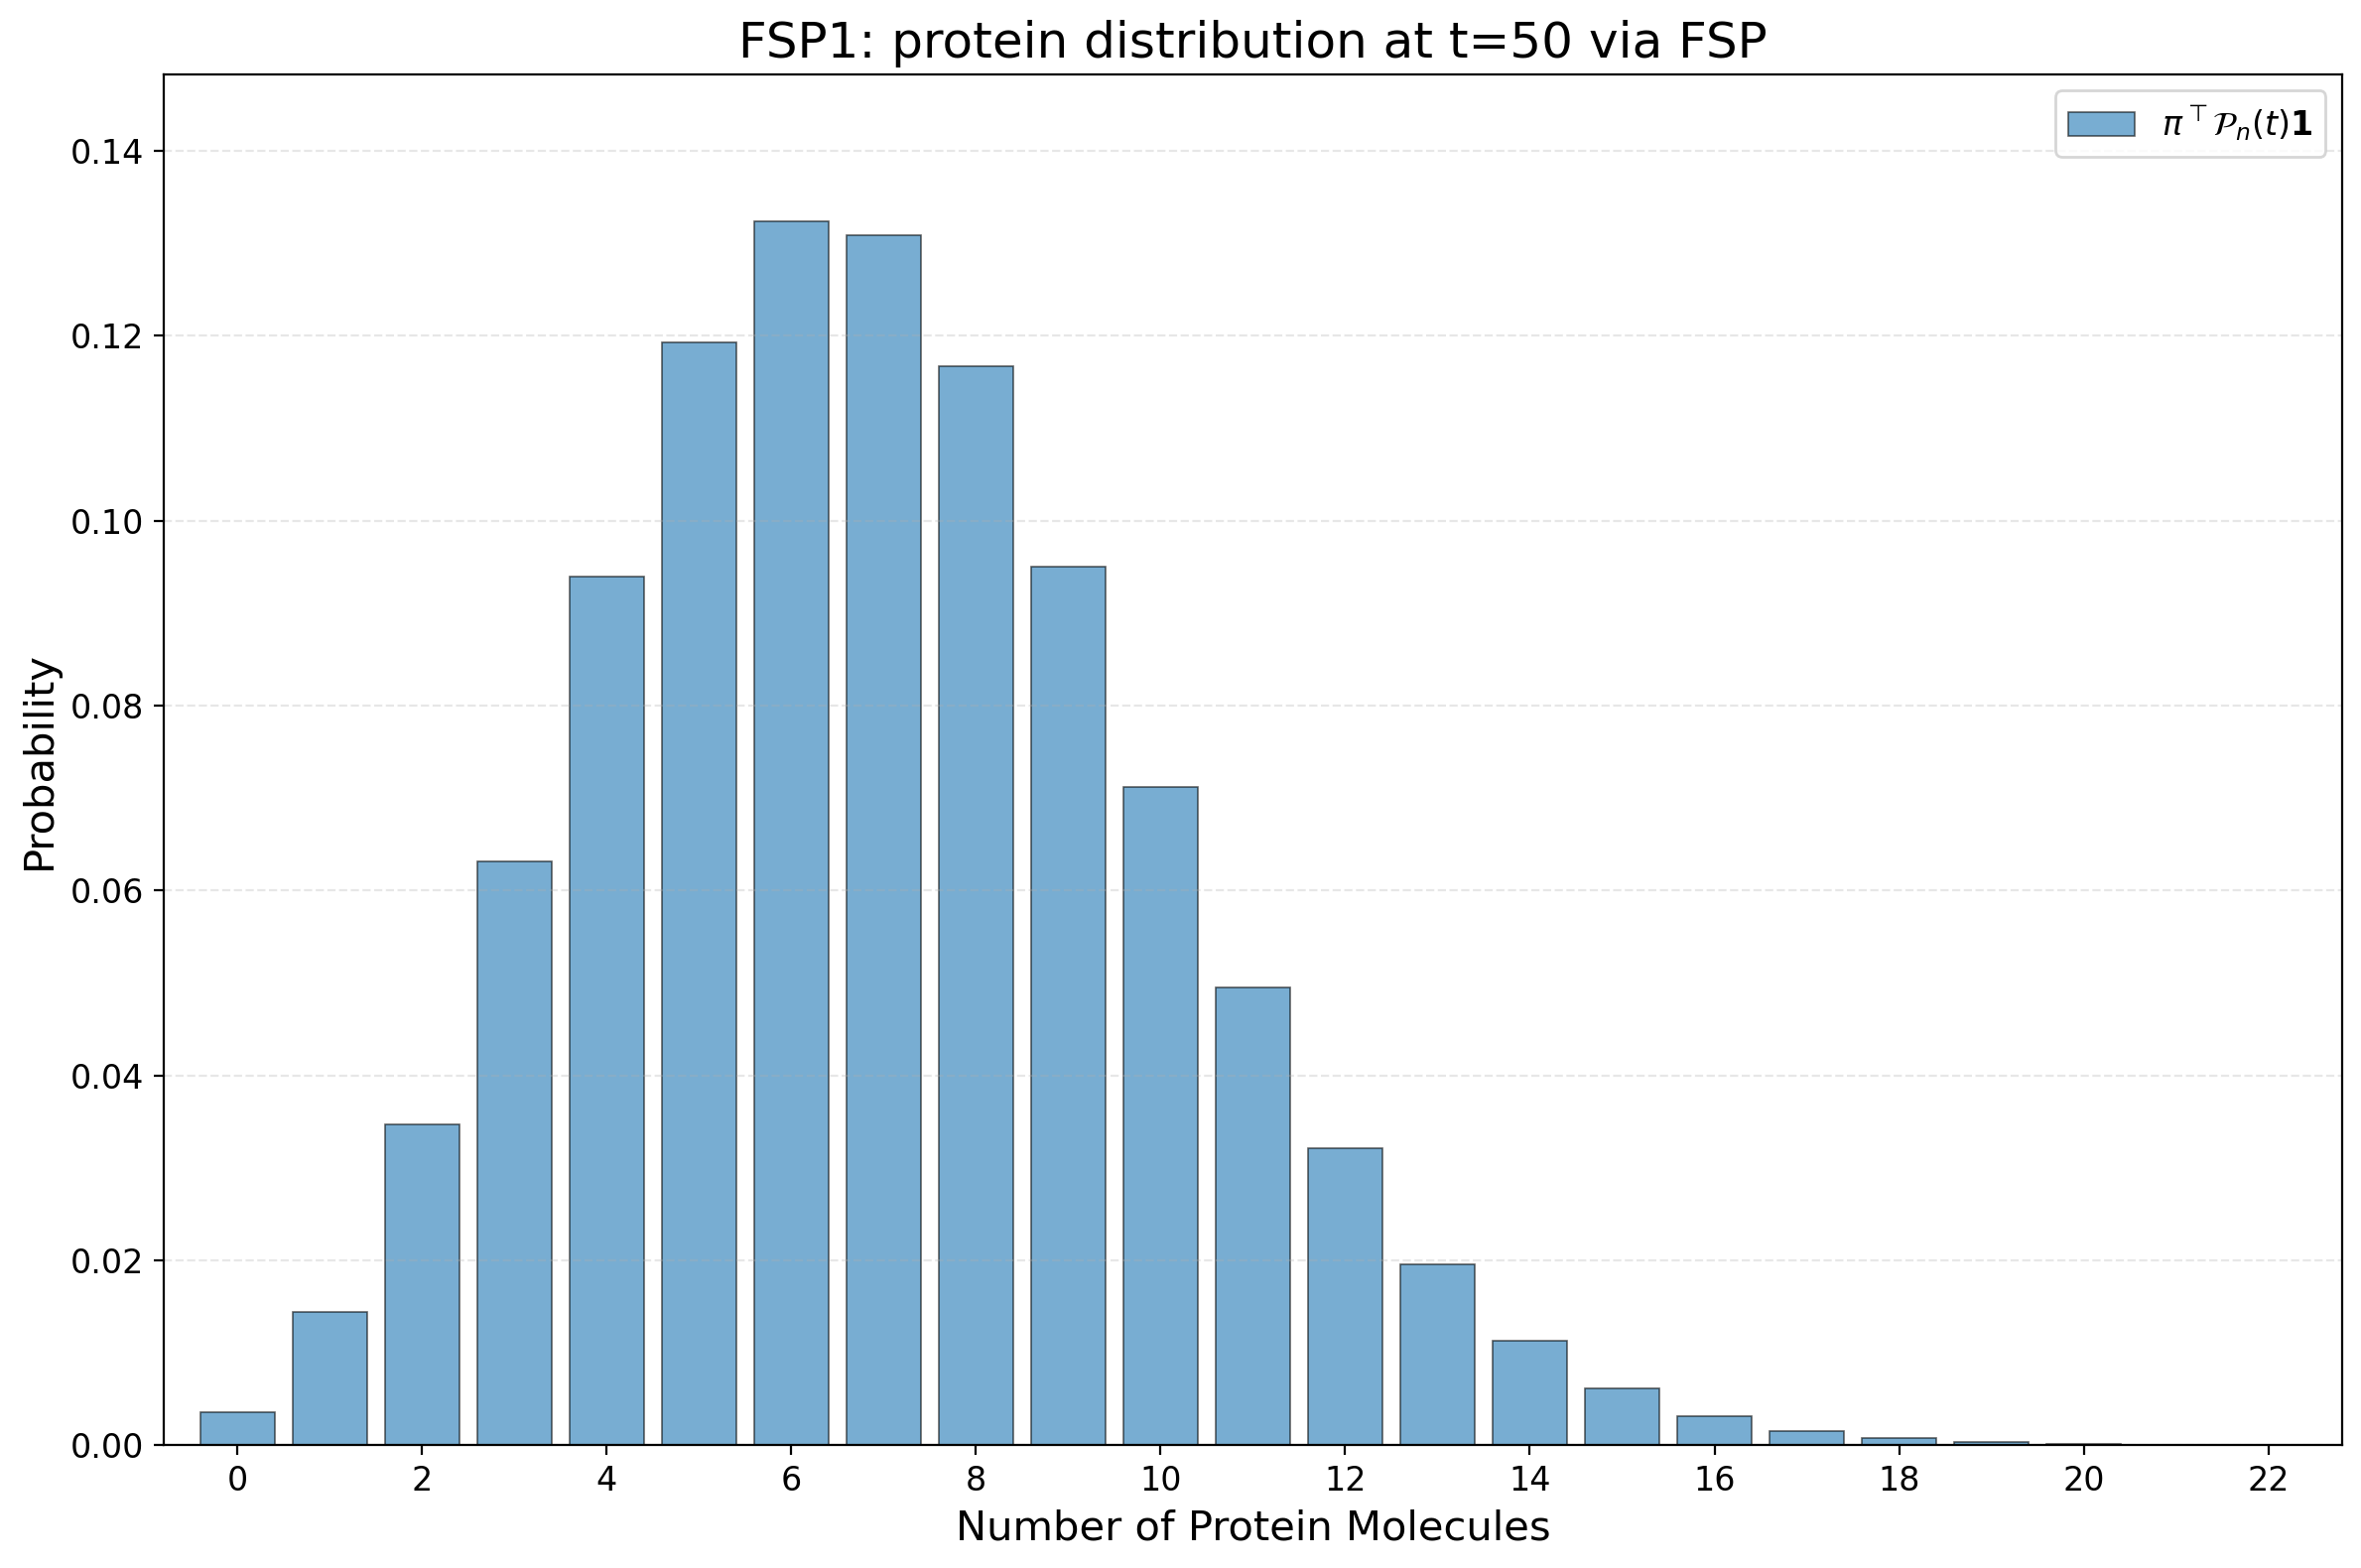

Pmax =   20, sink probability = 4.578e-01
Pmax =   40, sink probability = 1.766e-07
Pmax =   80, sink probability = 1.859e-26

========== FSP2 ==========
Same matrices as FSP1, with lambda=0.2.
Execution time: 0.3440 seconds
Final Pmax: 80
Sink probability: 1.859e-26
Probability retained: 1.000000000000
Mean protein count: 8.85416667
Protein-count variance: 12.89519371
Stationary distribution pi: [0.33333333 0.33333333 0.33333333]
Saved PMF to: fsp_results/FSP2.npy


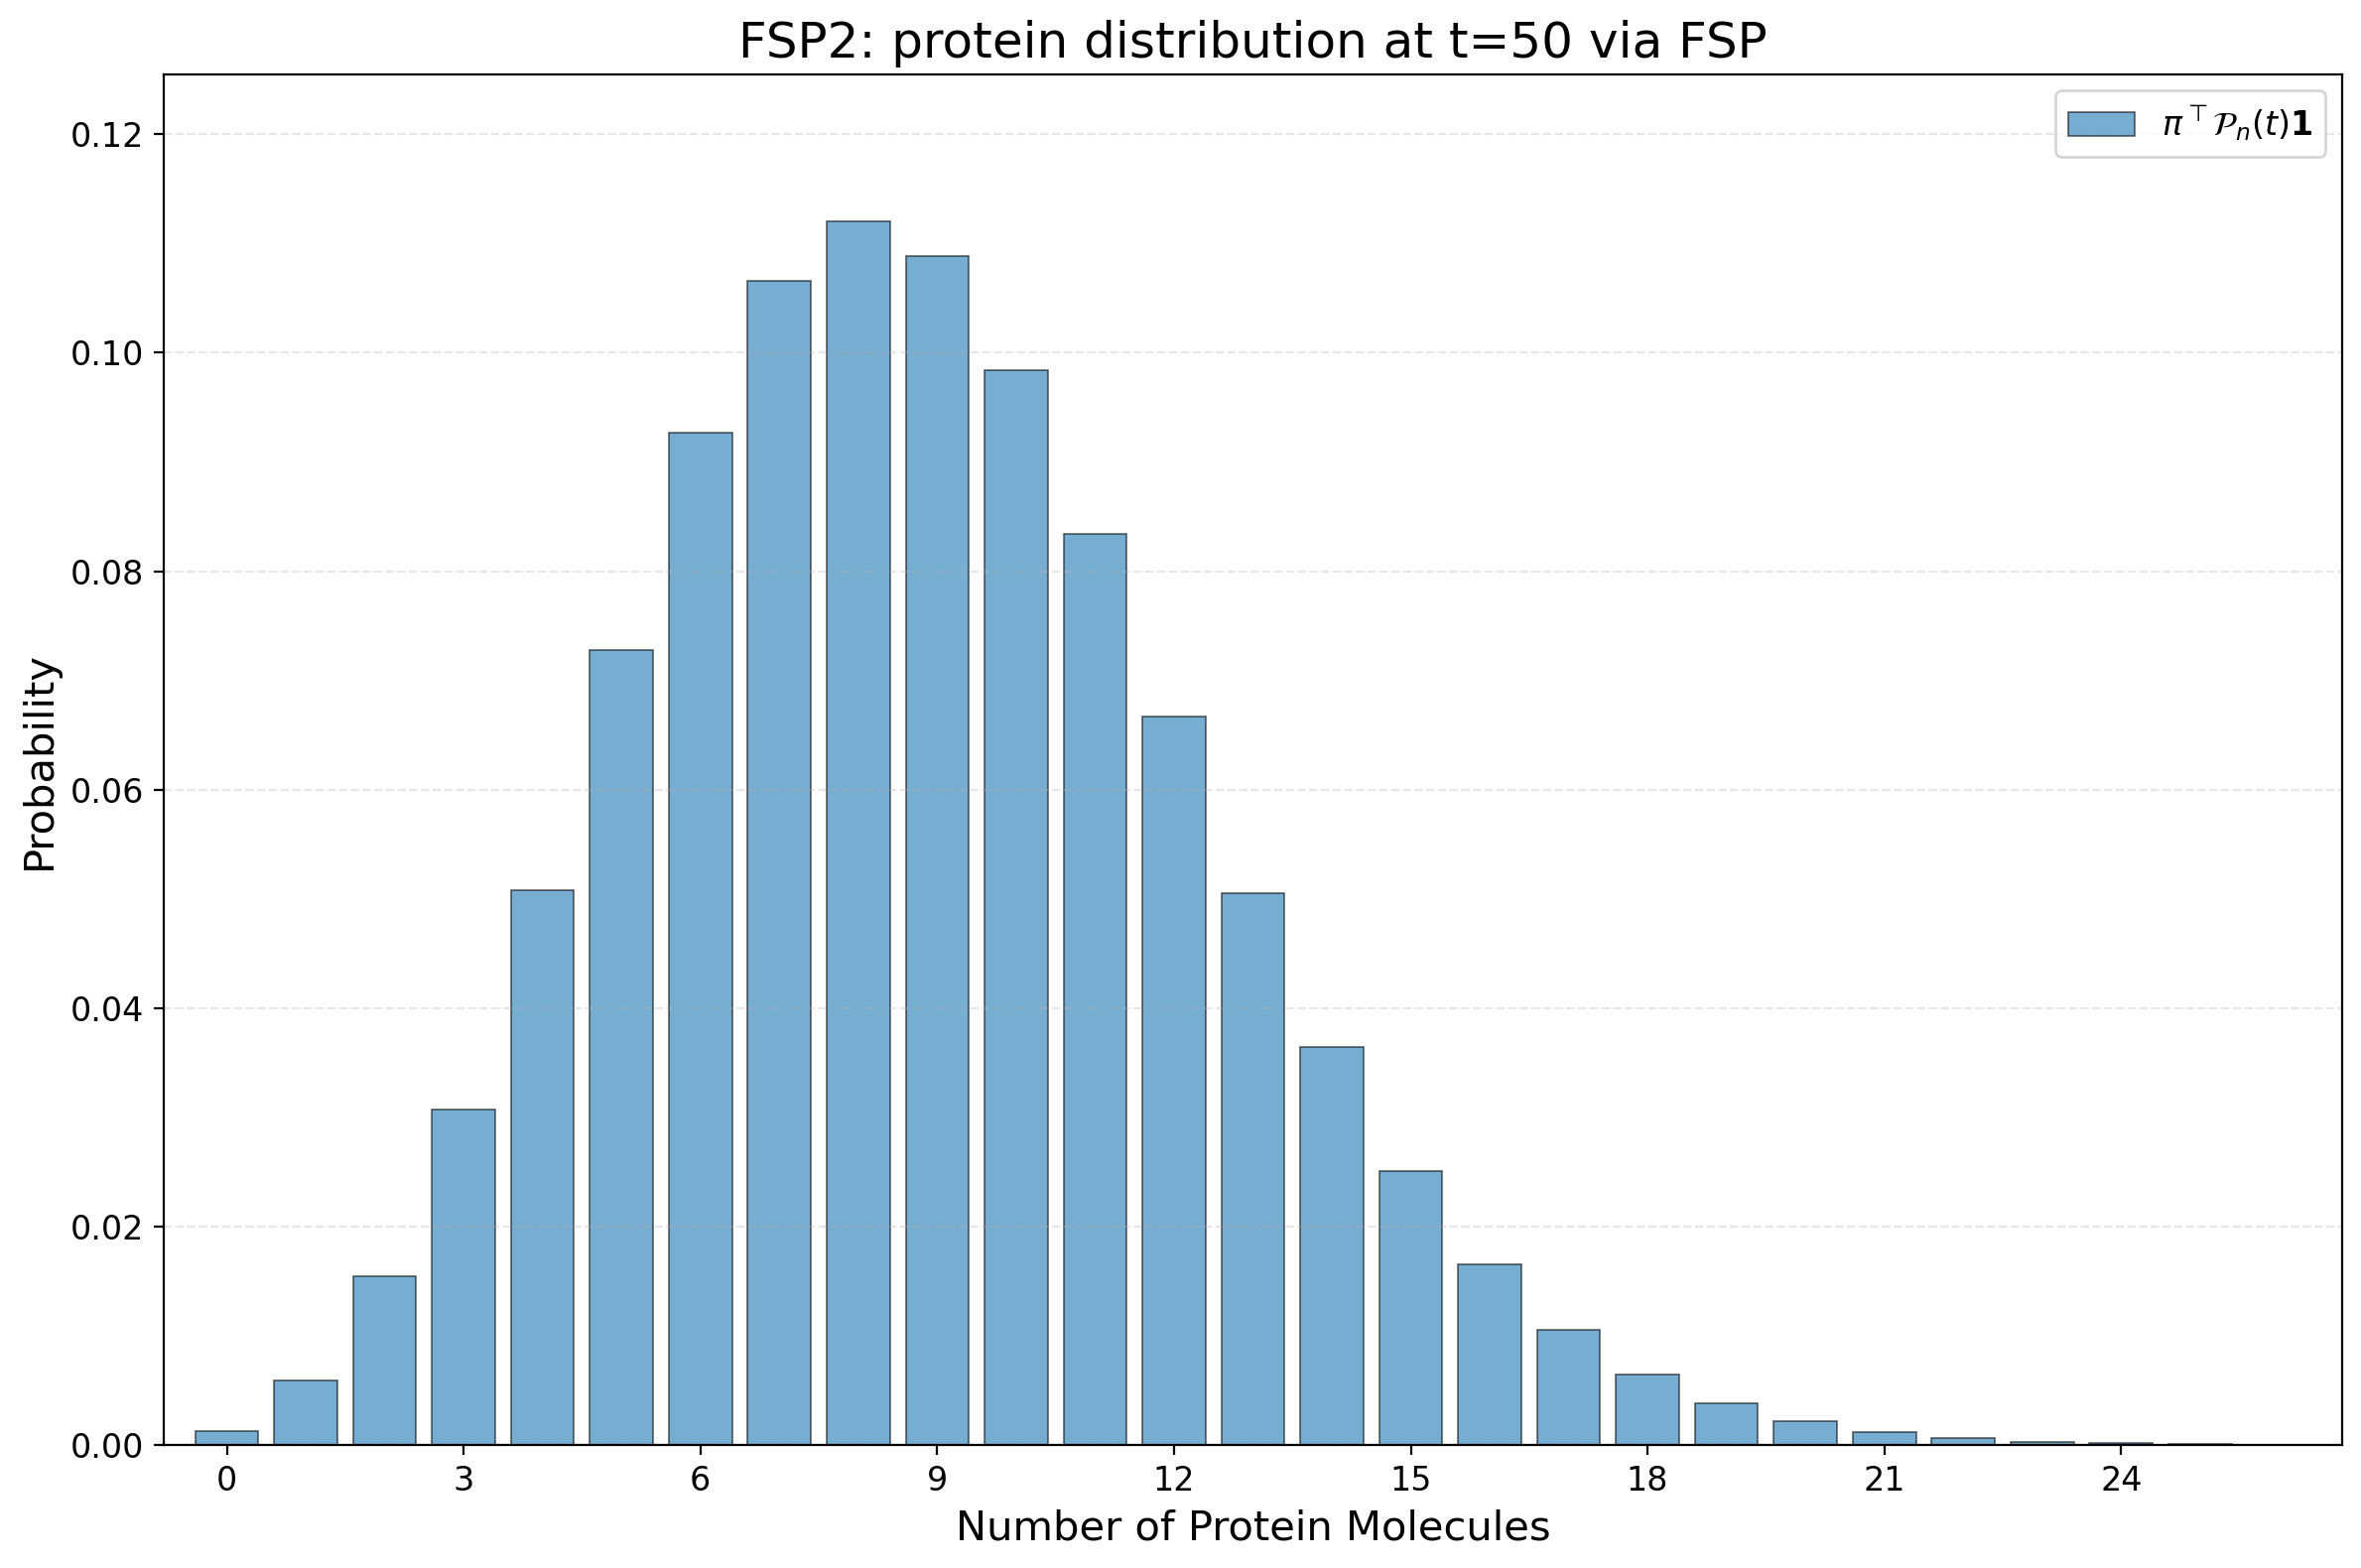

Pmax =   20, sink probability = 2.997e-04
Pmax =   40, sink probability = 2.960e-12
Pmax =   80, sink probability = 1.151e-30

========== FSP3 ==========
Two-state model with slow asymmetric switching.
Execution time: 0.1839 seconds
Final Pmax: 80
Sink probability: 1.151e-30
Probability retained: 1.000000000000
Mean protein count: 0.81632653
Protein-count variance: 3.29862557
Stationary distribution pi: [0.8 0.2]
Saved PMF to: fsp_results/FSP3.npy


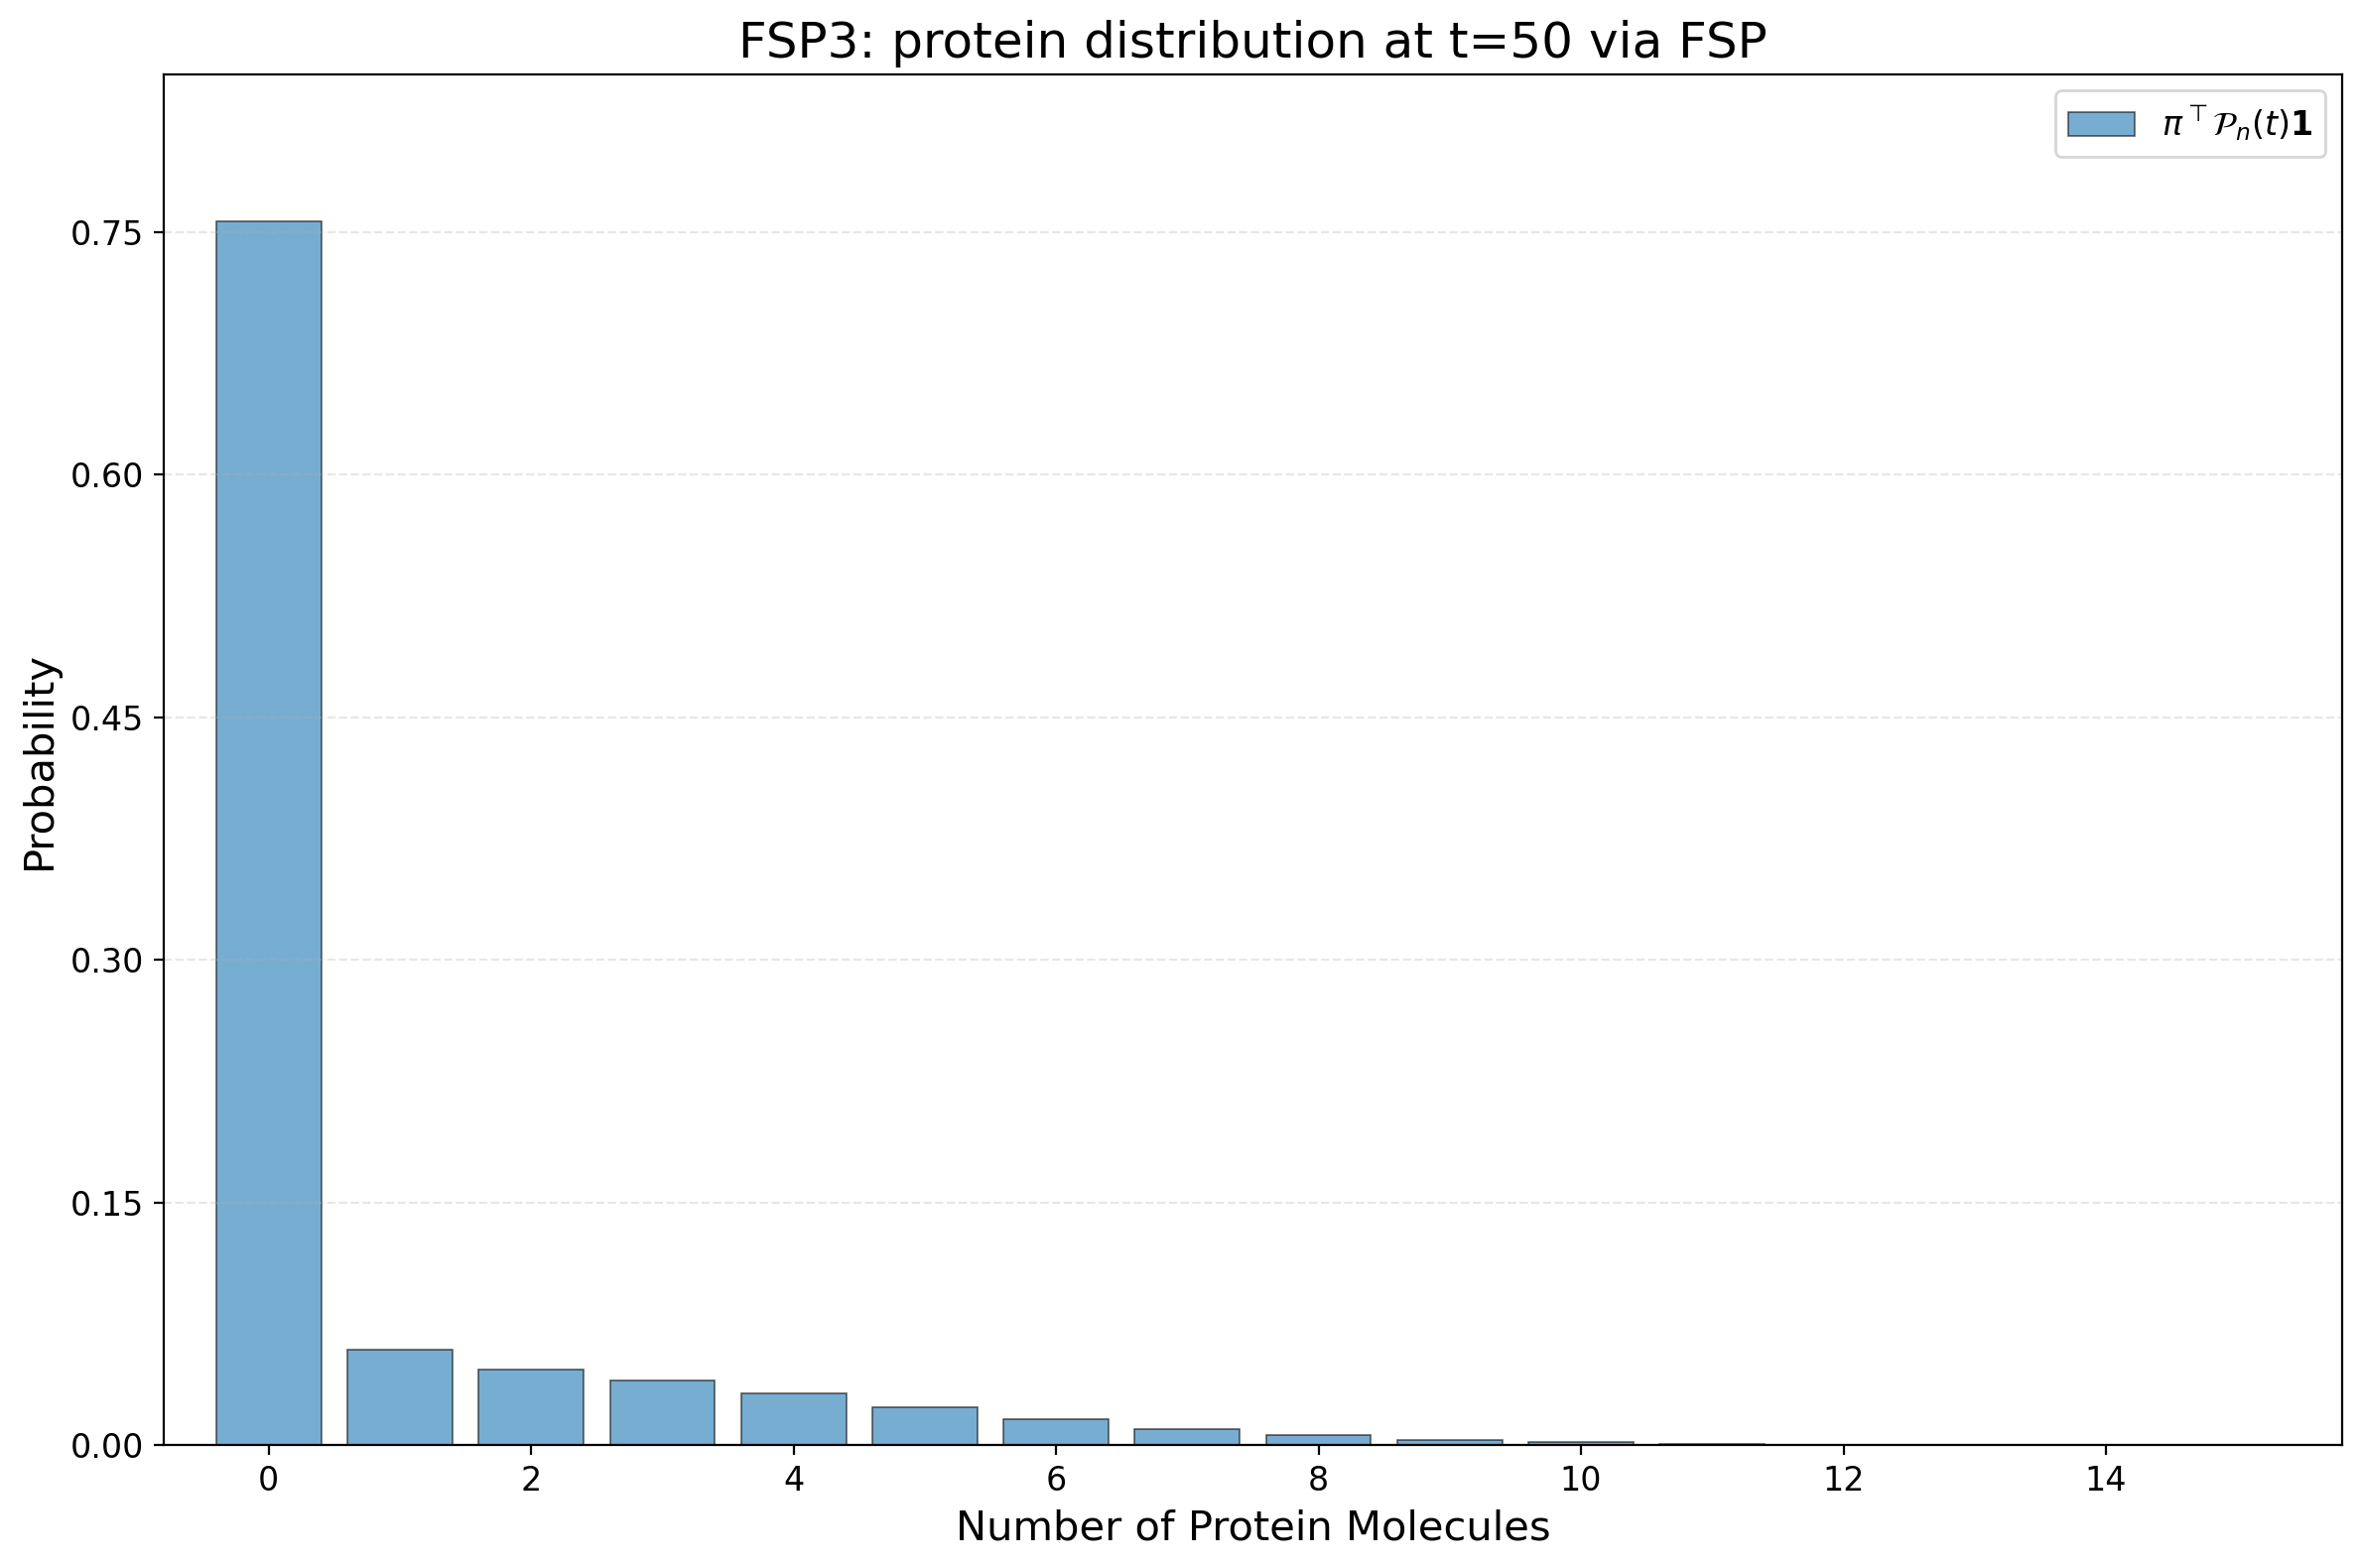

Pmax =   20, sink probability = 2.939e-05
Pmax =   40, sink probability = 9.734e-14

========== FSP4 ==========
Same burst structure as FSP3, with faster switching.
Execution time: 0.0889 seconds
Final Pmax: 40
Sink probability: 9.734e-14
Probability retained: 1.000000000000
Mean protein count: 1.63265306
Protein-count variance: 2.69584642
Stationary distribution pi: [0.6 0.4]
Saved PMF to: fsp_results/FSP4.npy


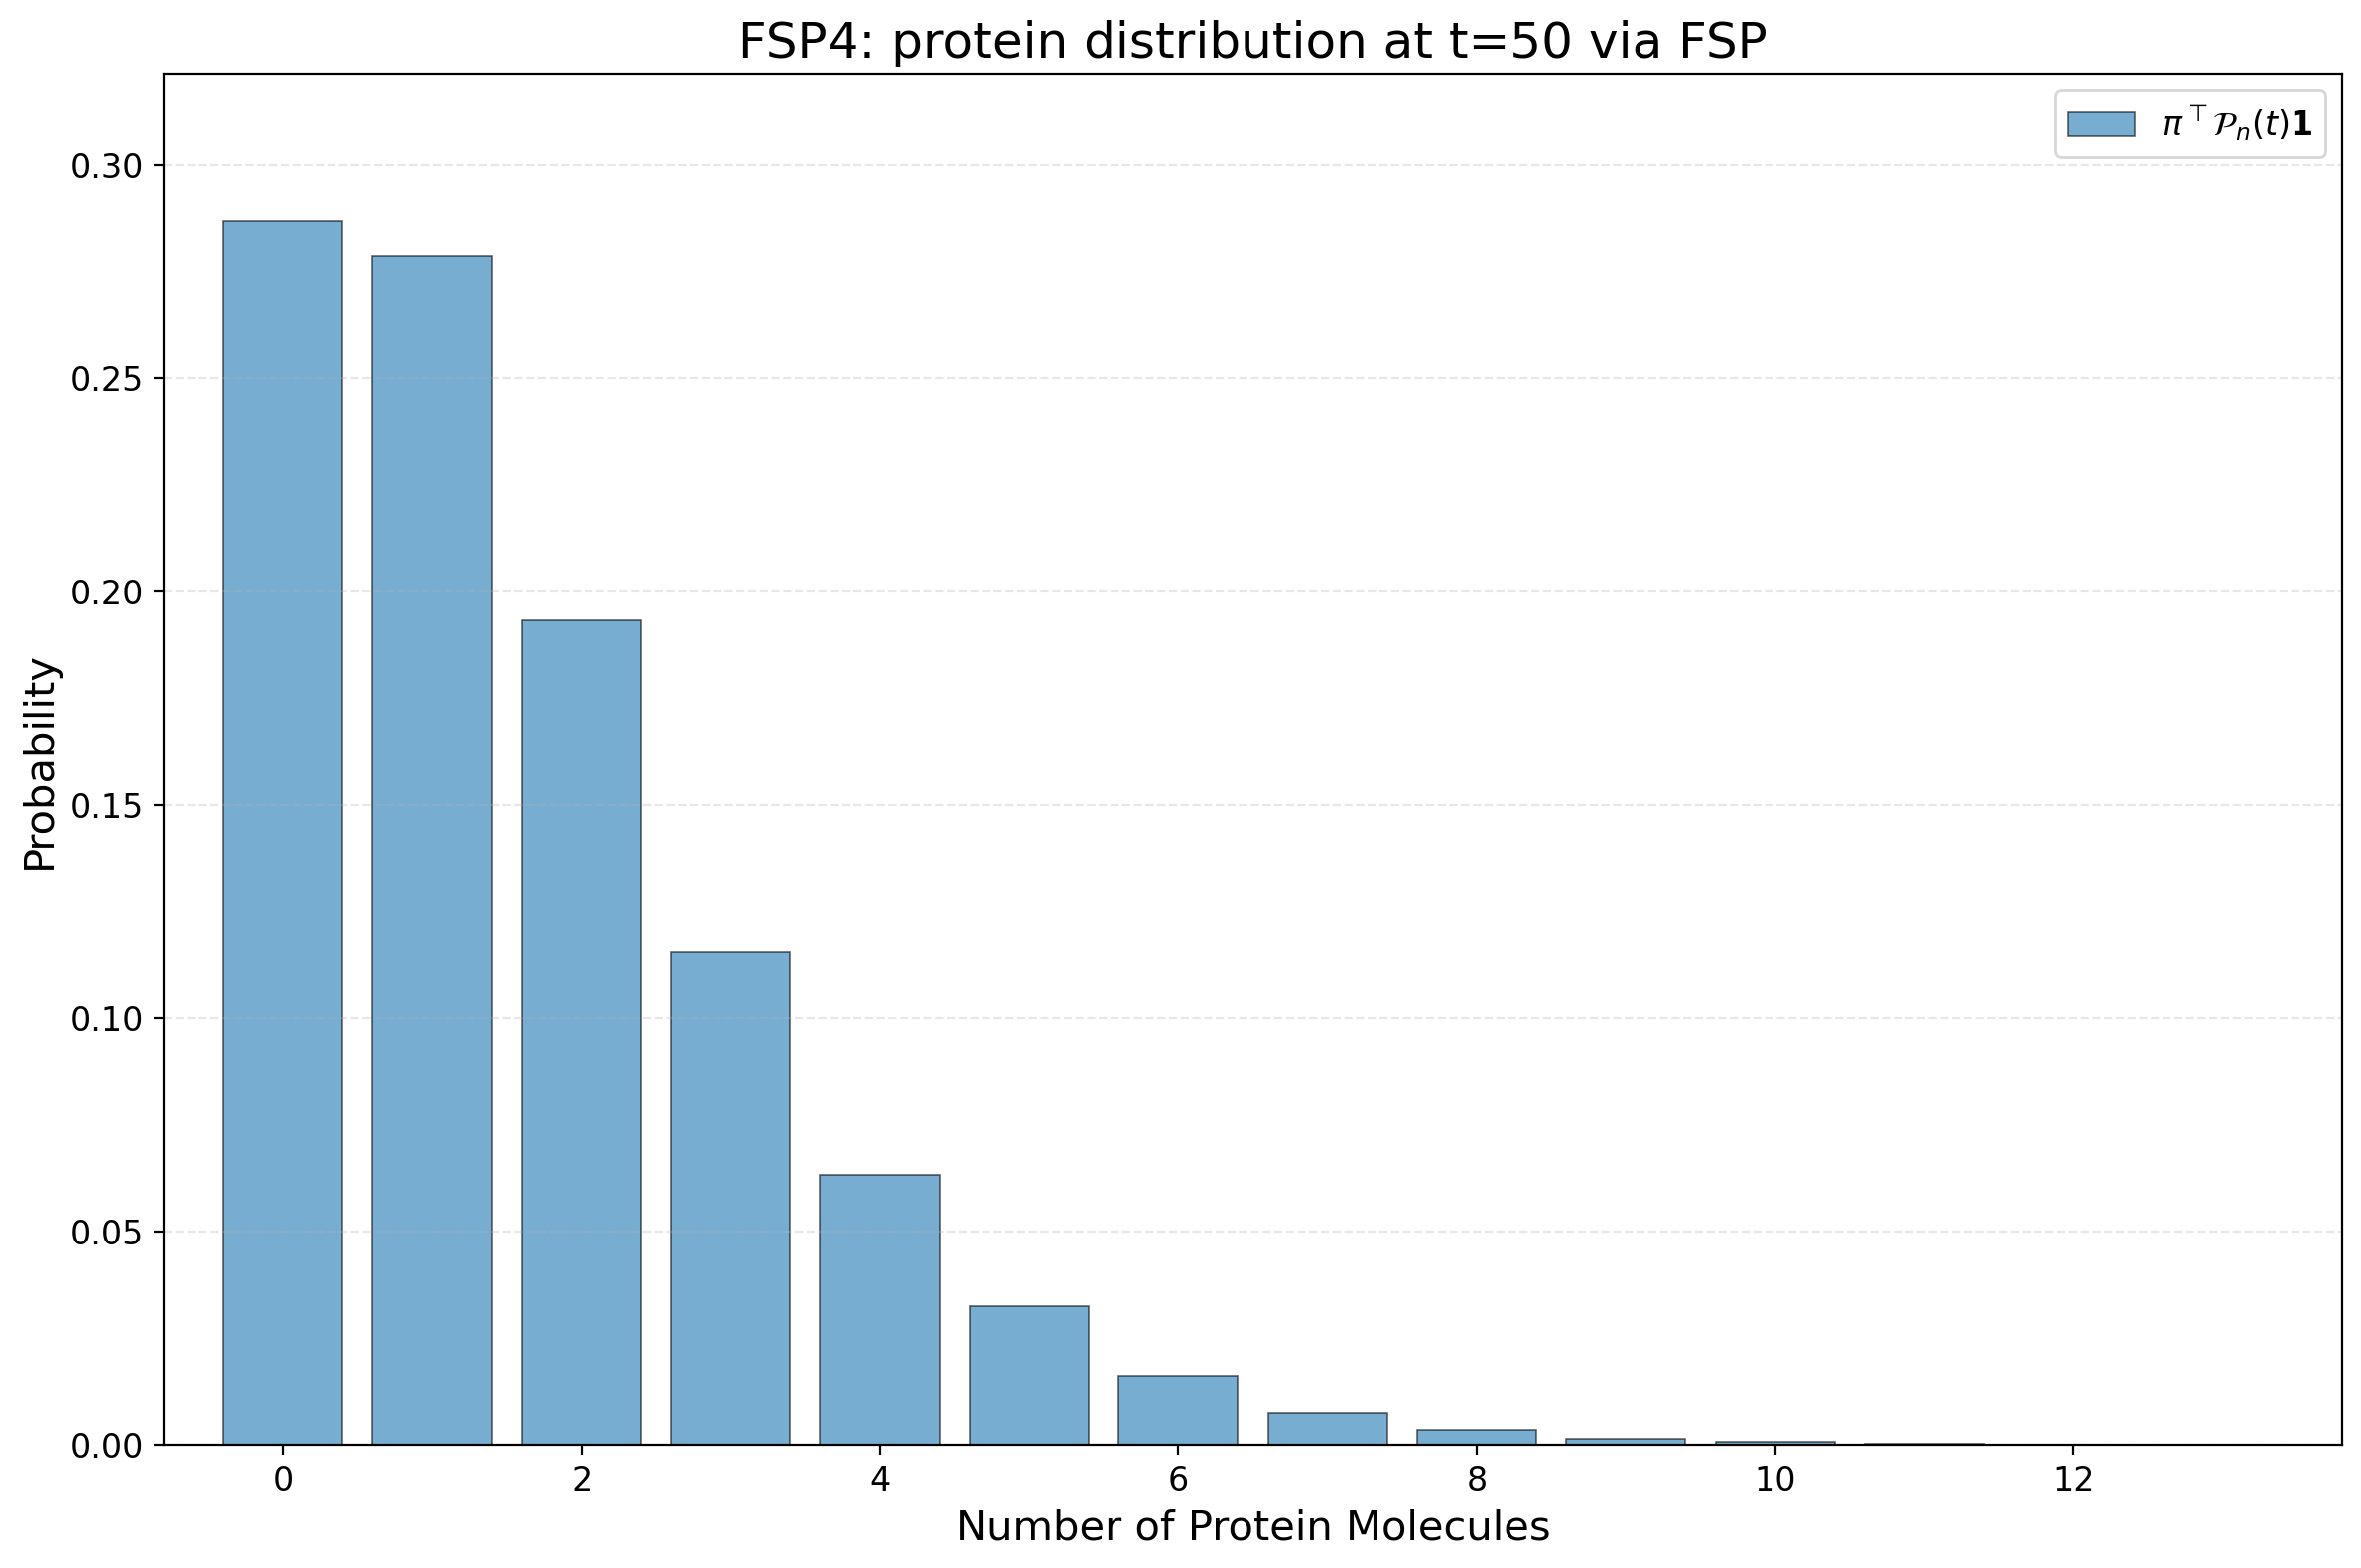

Pmax =   20, sink probability = 5.624e-04
Pmax =   40, sink probability = 1.228e-13

========== FSP5 ==========
Five-state model with three active burst states.
Execution time: 0.0887 seconds
Final Pmax: 40
Sink probability: 1.228e-13
Probability retained: 1.000000000000
Mean protein count: 2.77960526
Protein-count variance: 7.51546347
Stationary distribution pi: [0.05263158 0.07894737 0.15789474 0.23684211 0.47368421]
Saved PMF to: fsp_results/FSP5.npy


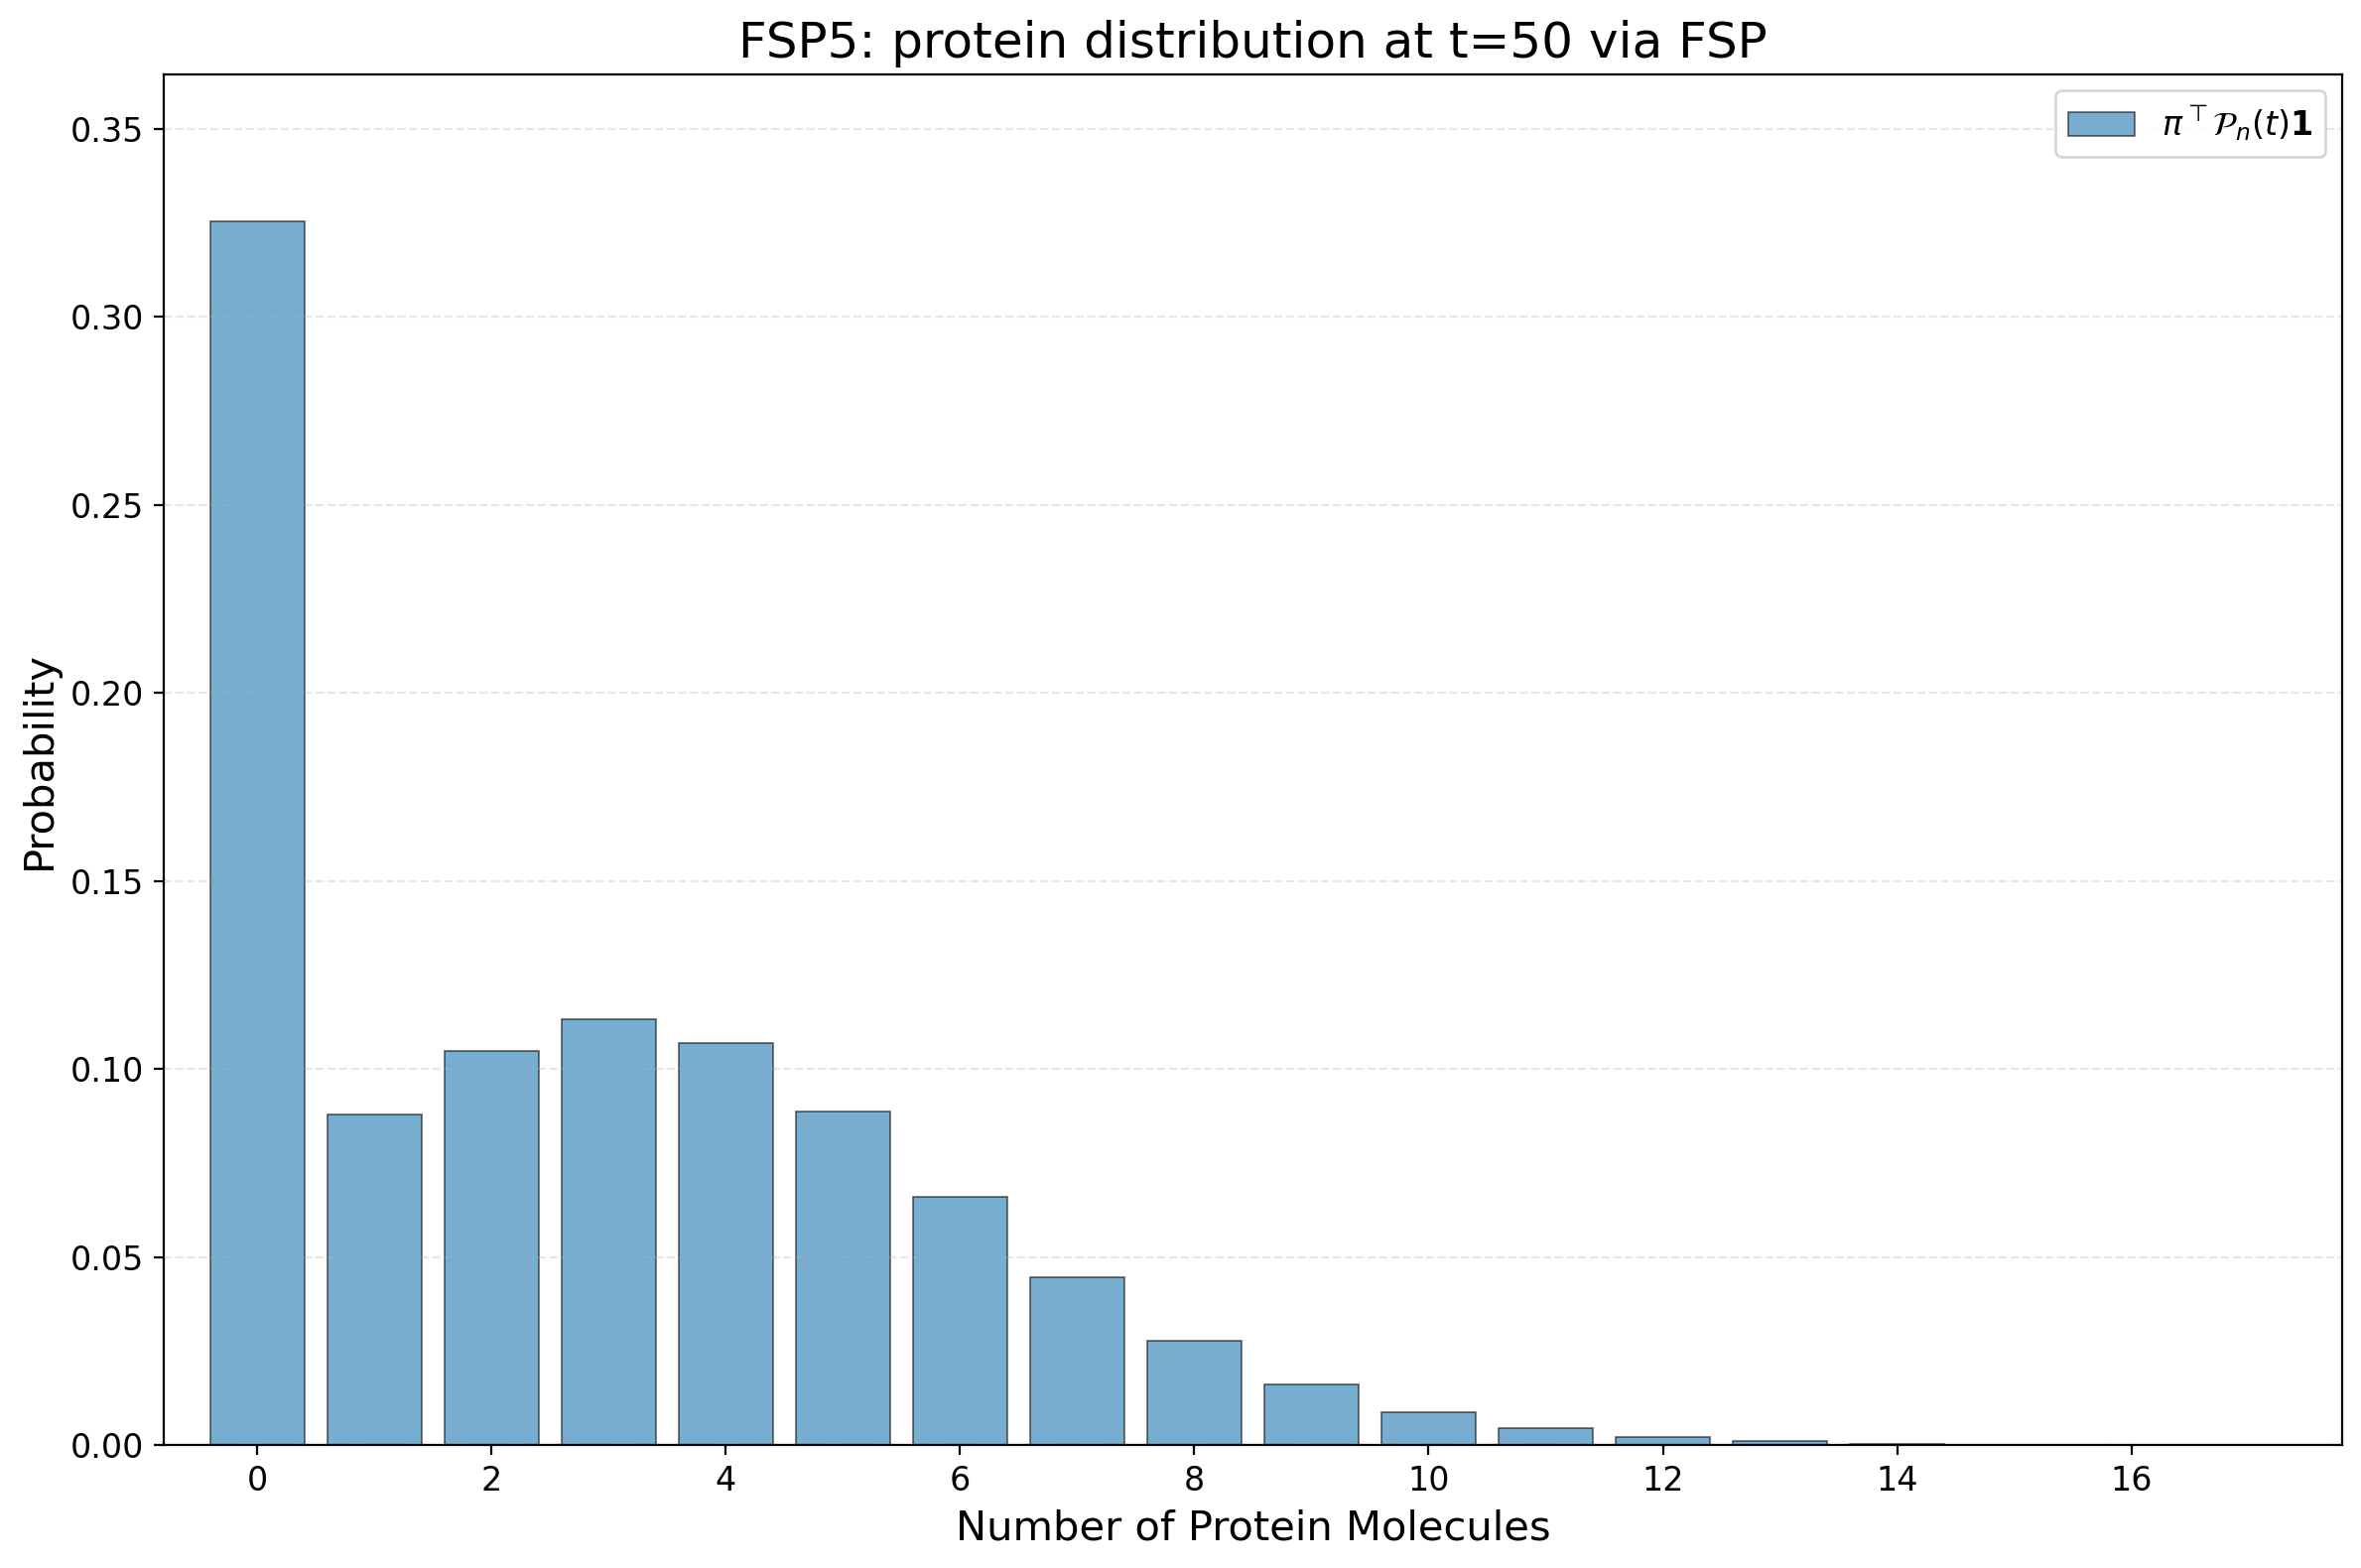

Pmax =   20, sink probability = 9.877e-01
Pmax =   40, sink probability = 1.788e-05
Pmax =   80, sink probability = 5.476e-27

========== FSP6 ==========
Five-state model with widely separated burst rates.
Execution time: 4.7745 seconds
Final Pmax: 80
Sink probability: 5.476e-27
Probability retained: 1.000000000000
Mean protein count: 7.53736192
Protein-count variance: 32.80804611
Stationary distribution pi: [0.05263158 0.07894737 0.15789474 0.23684211 0.47368421]
Saved PMF to: fsp_results/FSP6.npy


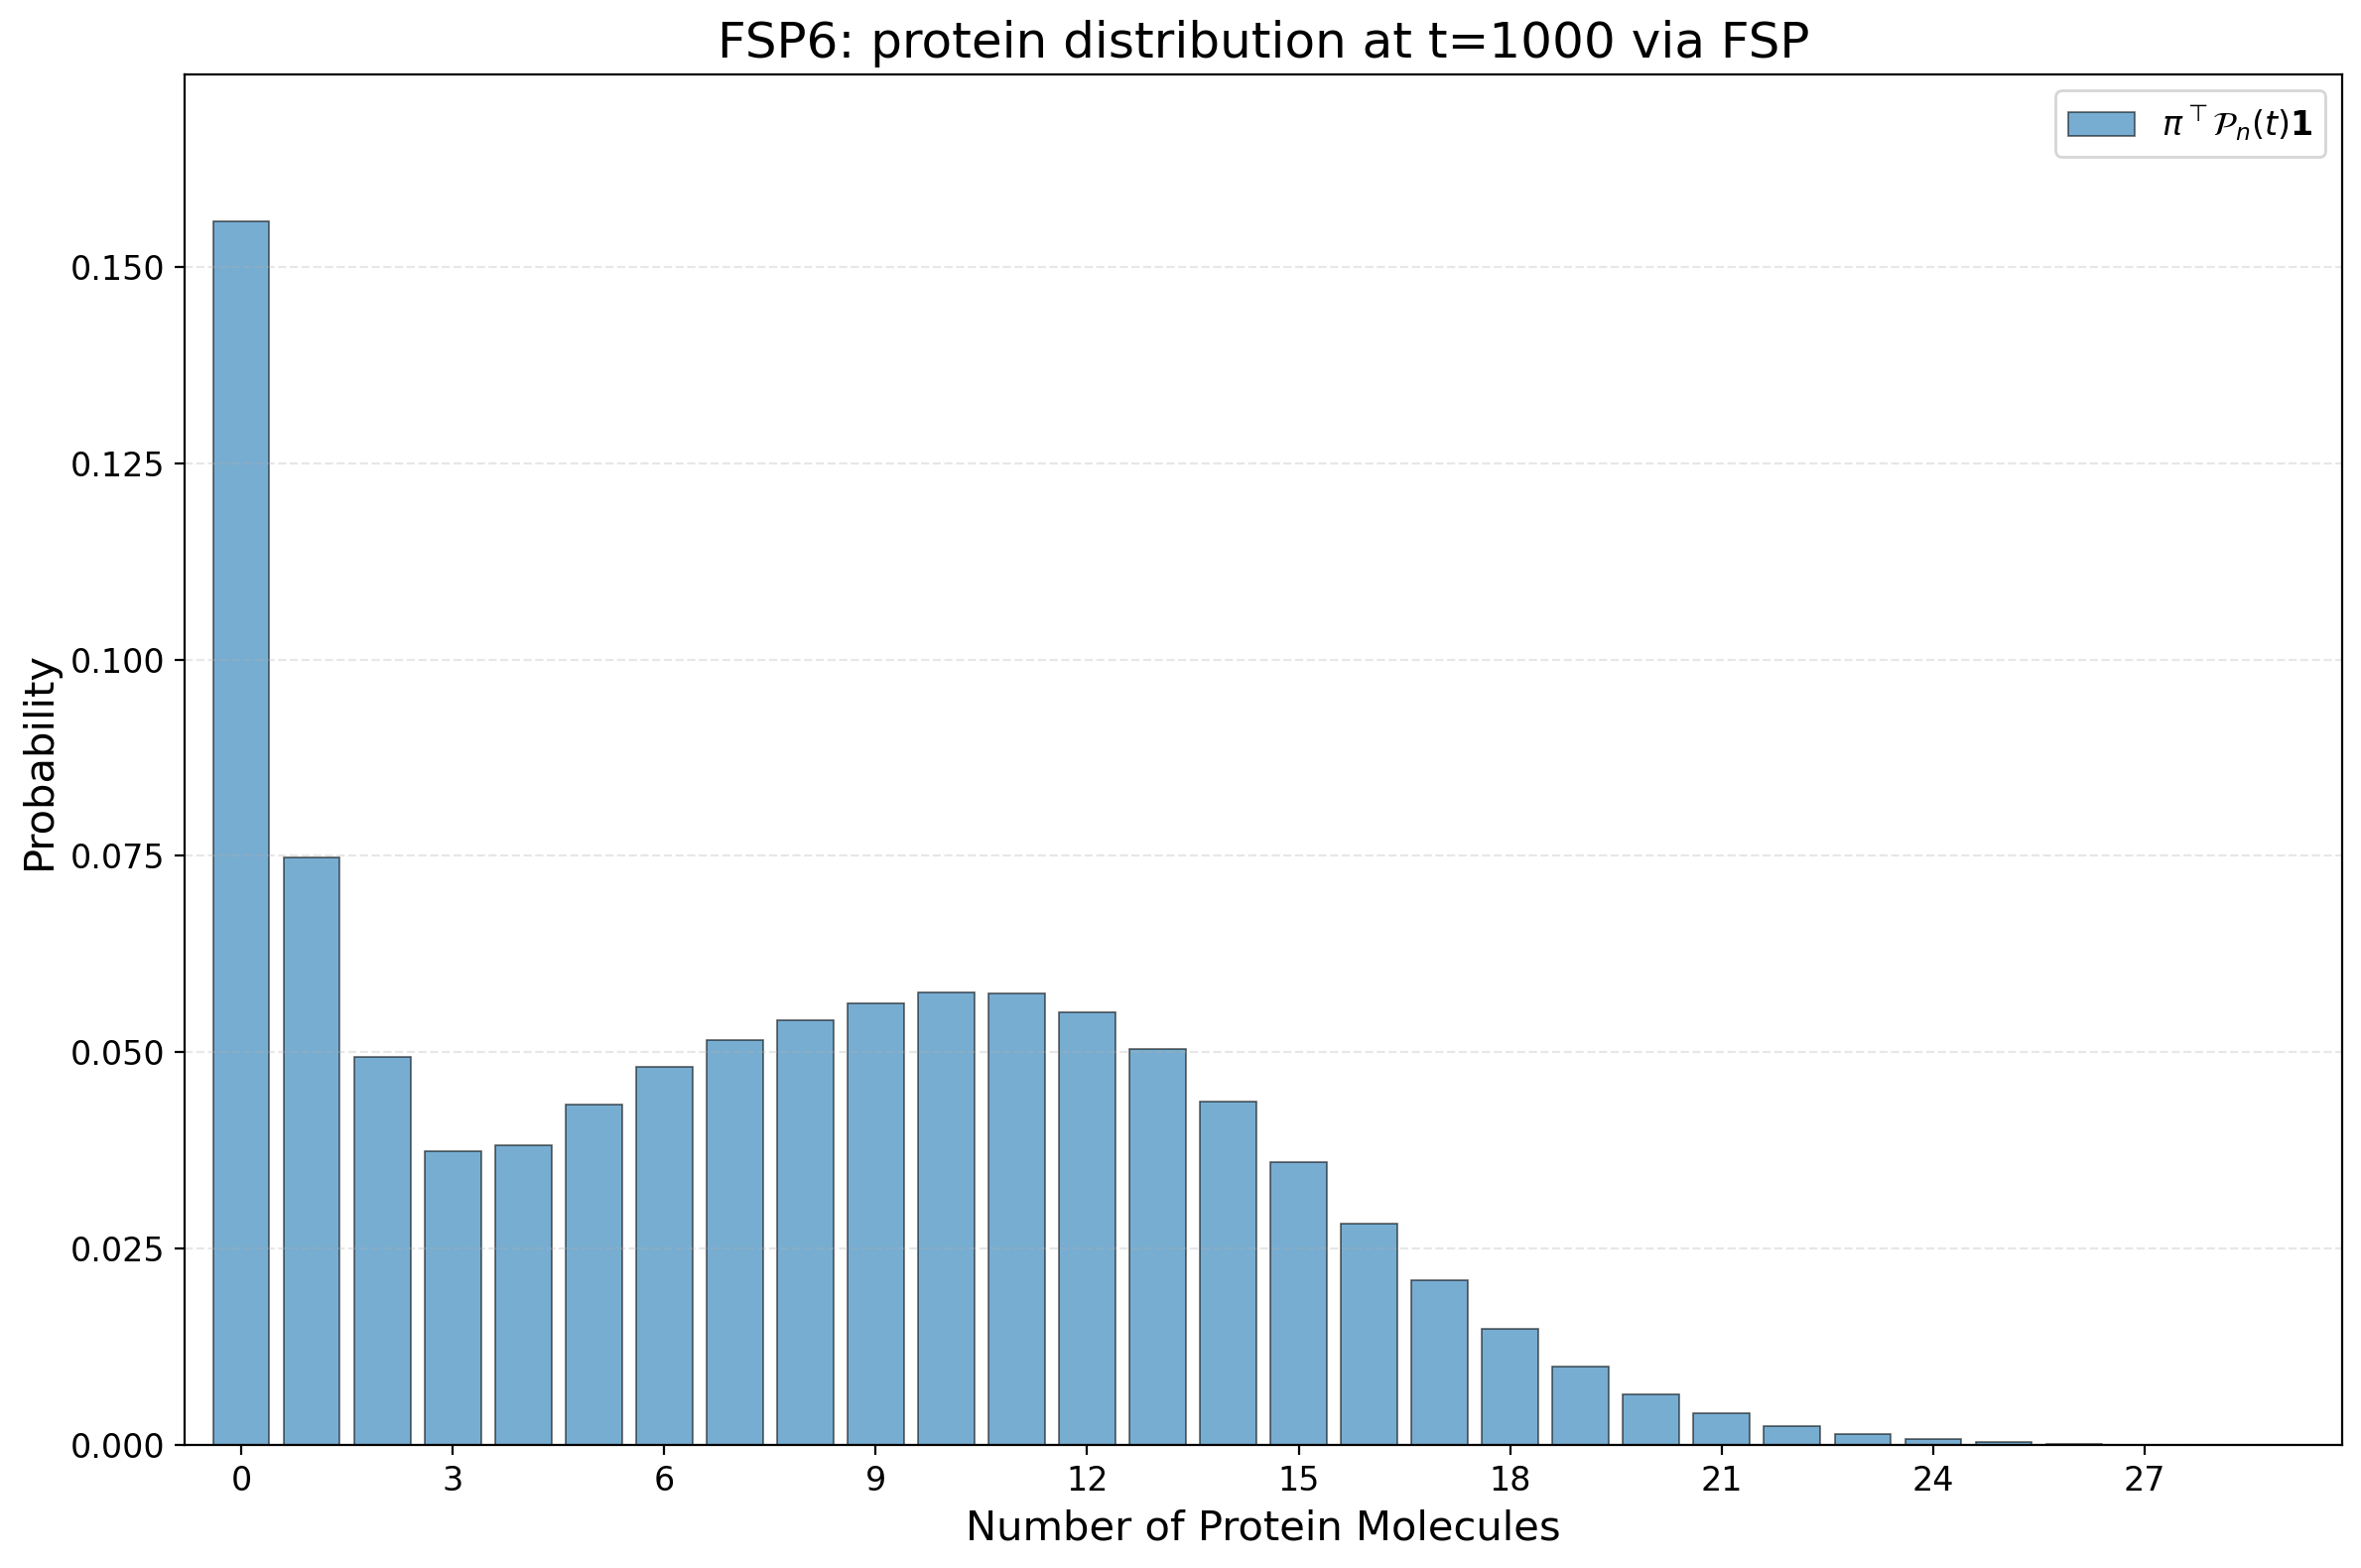

Pmax =   20, sink probability = 9.796e-01
Pmax =   40, sink probability = 2.628e-07
Pmax =   80, sink probability = 6.524e-33

========== FSP7 ==========
Same switching as FSP6, with lower burst rates and lambda.
Execution time: 4.7341 seconds
Final Pmax: 80
Sink probability: 6.524e-33
Probability retained: 1.000000000000
Mean protein count: 5.52908587
Protein-count variance: 33.23737331
Stationary distribution pi: [0.05263158 0.07894737 0.15789474 0.23684211 0.47368421]
Saved PMF to: fsp_results/FSP7.npy


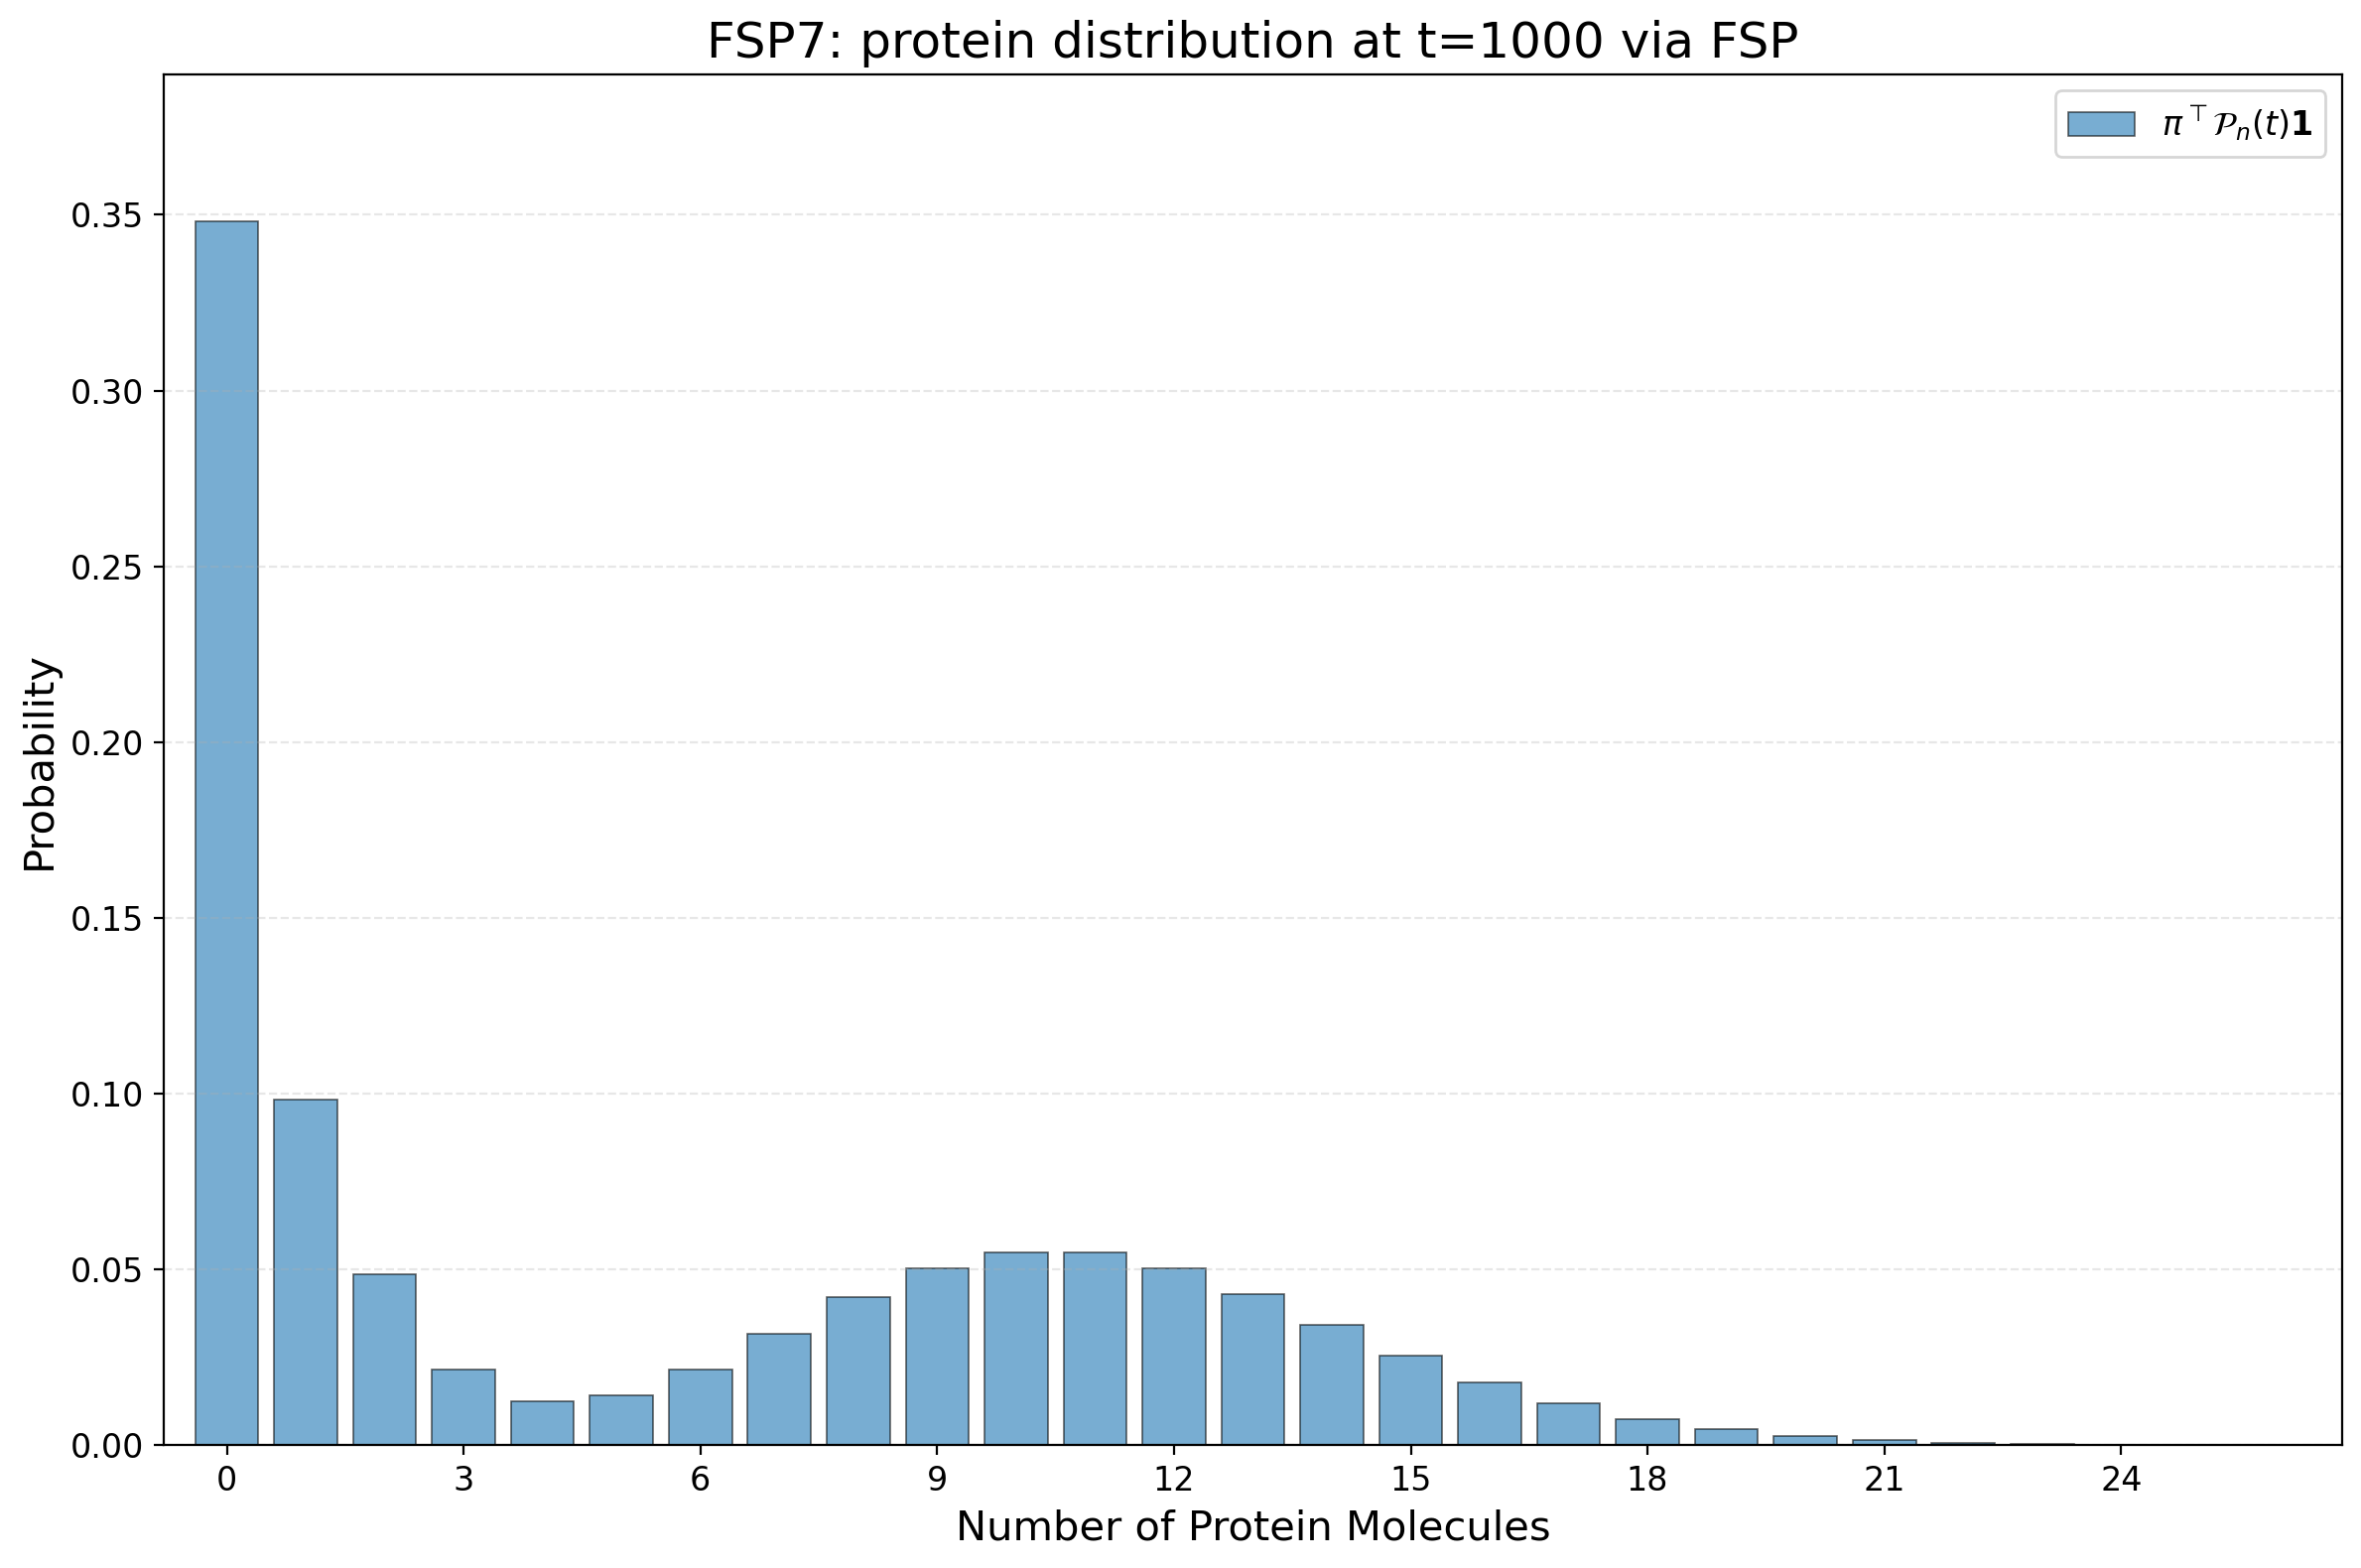

Pmax =   20, sink probability = 8.942e-01
Pmax =   40, sink probability = 2.297e-05
Pmax =   80, sink probability = 7.063e-27

========== FSP8 ==========
Ten states arranged in four slowly connected clusters.
Execution time: 19.5683 seconds
Final Pmax: 80
Sink probability: 7.063e-27
Probability retained: 1.000000000000
Mean protein count: 3.72839506
Protein-count variance: 23.02336552
Stationary distribution pi: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Saved PMF to: fsp_results/FSP8.npy


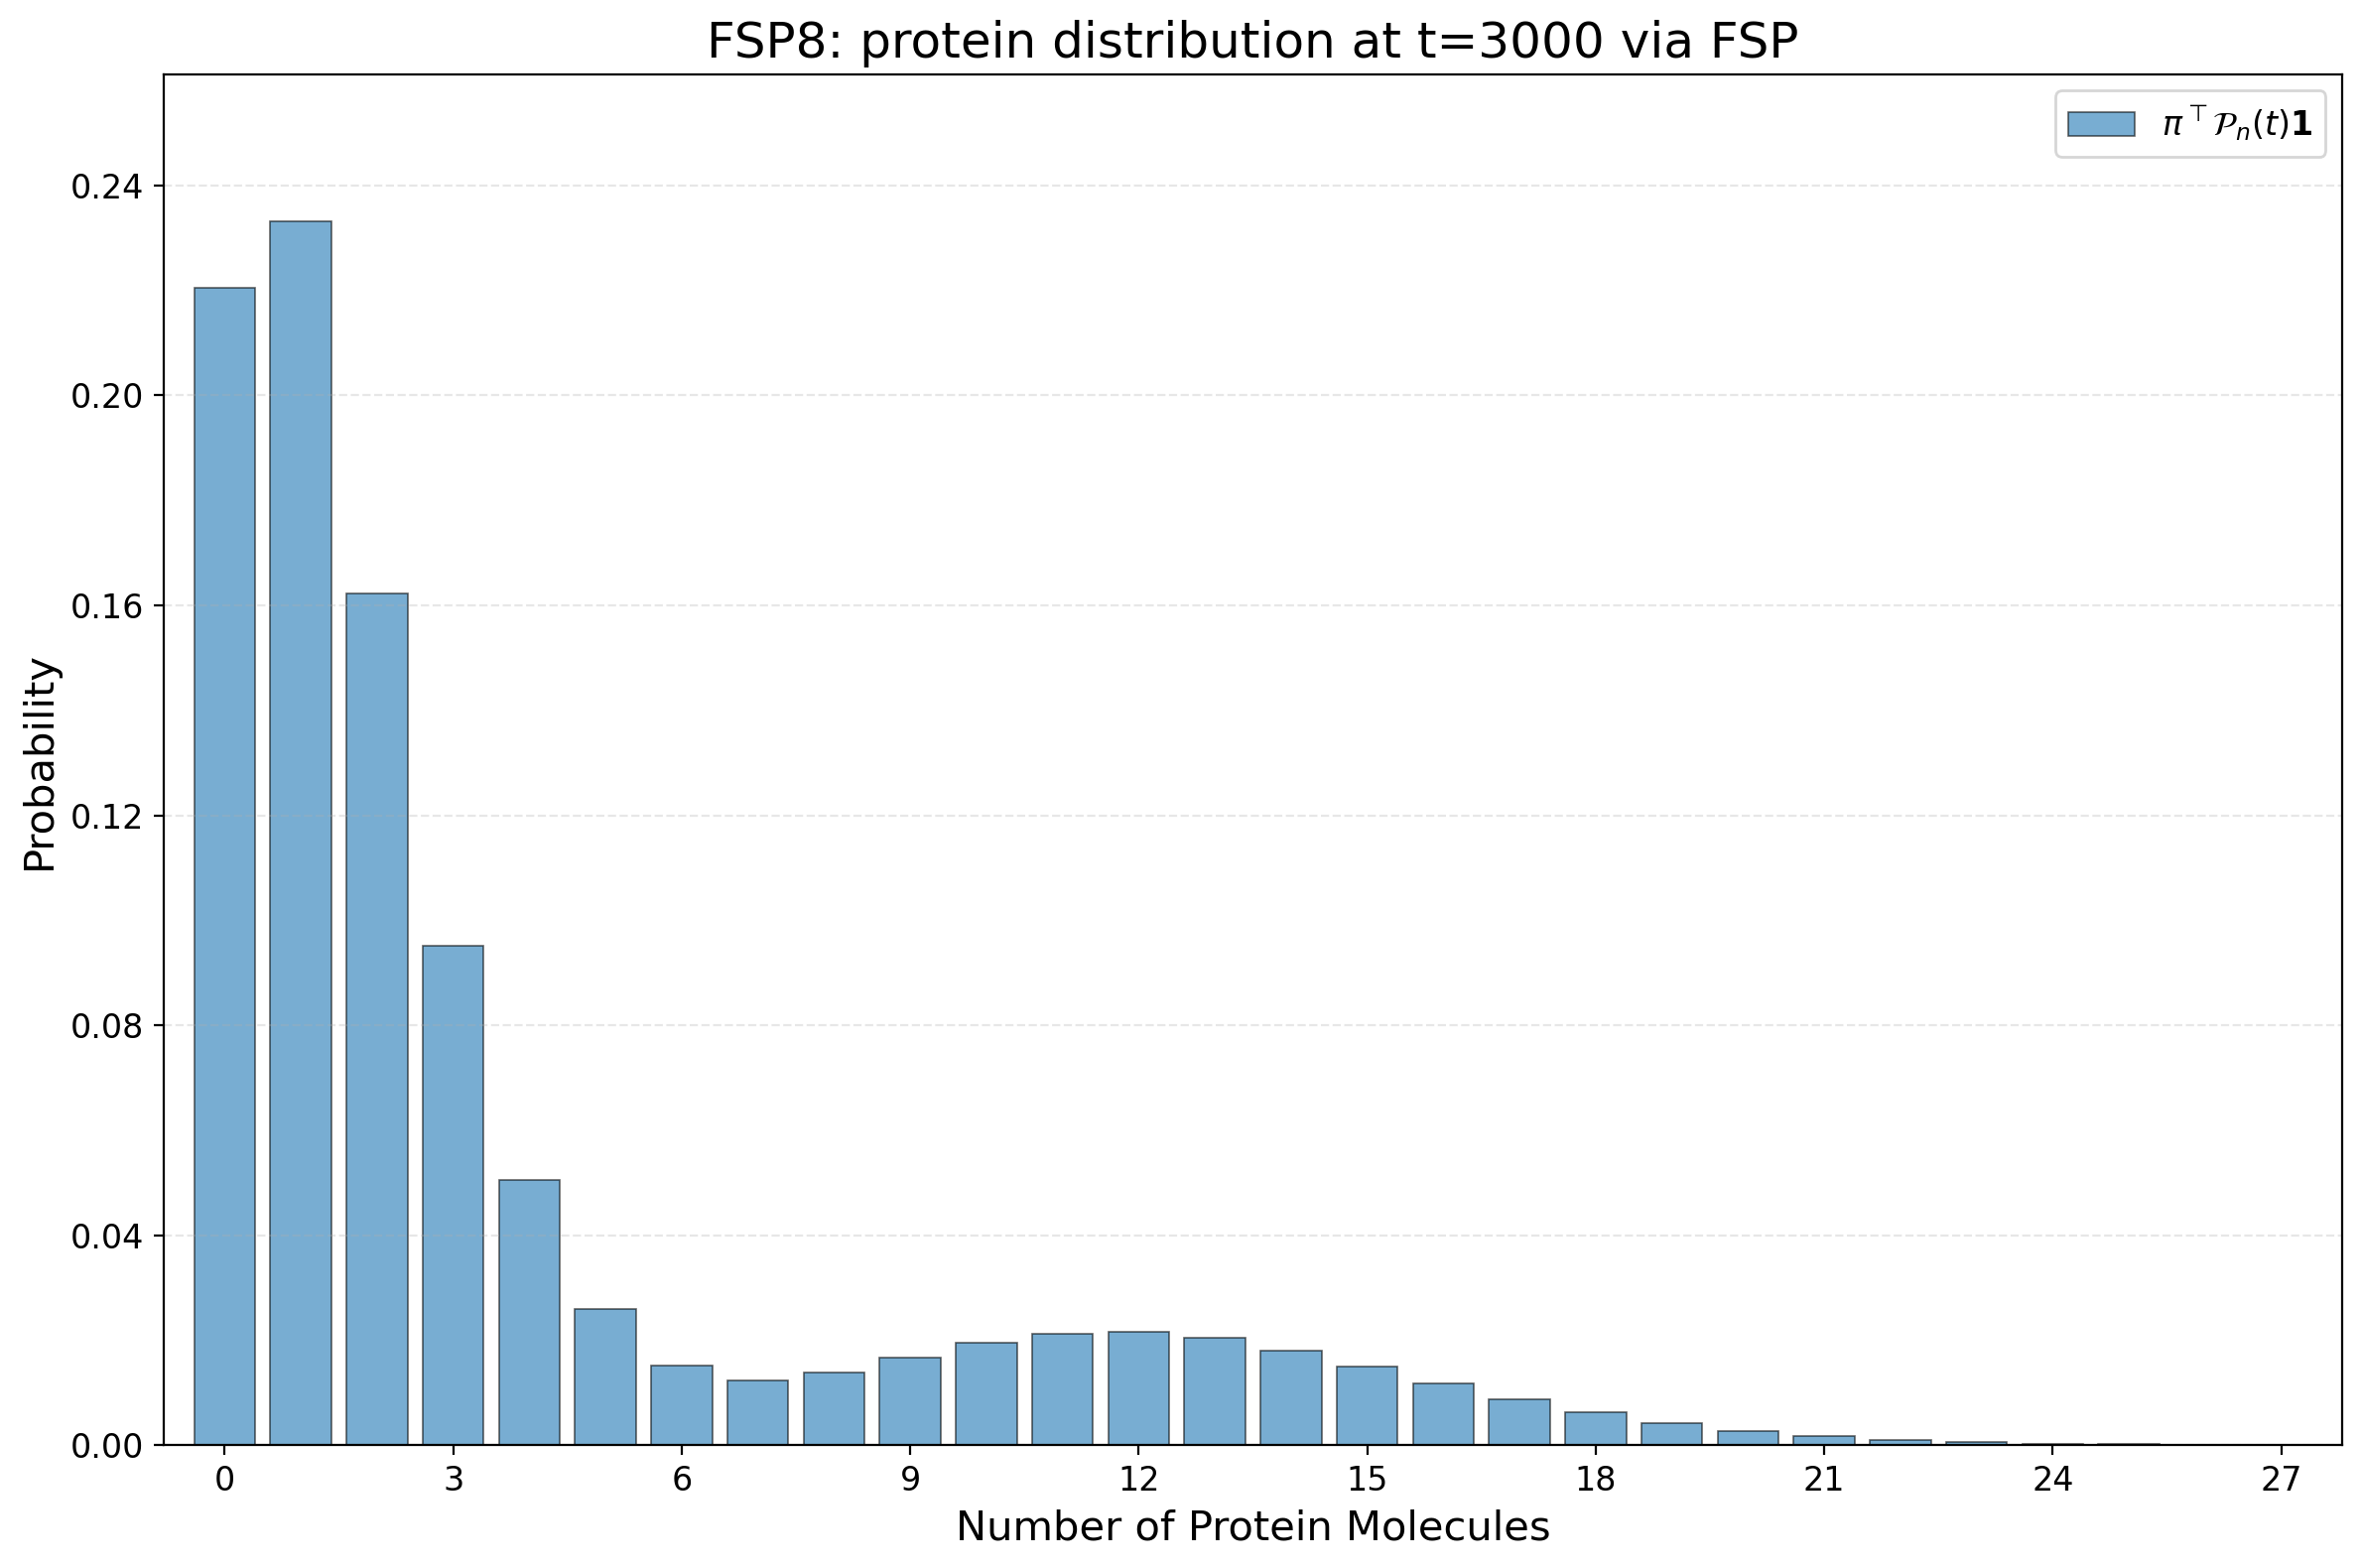

Pmax =   20, sink probability = 9.845e-01
Pmax =   40, sink probability = 7.749e-05
Pmax =   80, sink probability = 2.386e-26

========== FSP9 ==========
Ten states arranged in five groups with separated burst rates.
Execution time: 66.9439 seconds
Final Pmax: 80
Sink probability: 2.386e-26
Probability retained: 1.000000000000
Mean protein count: 5.58024691
Protein-count variance: 25.75239151
Stationary distribution pi: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Saved PMF to: fsp_results/FSP9.npy


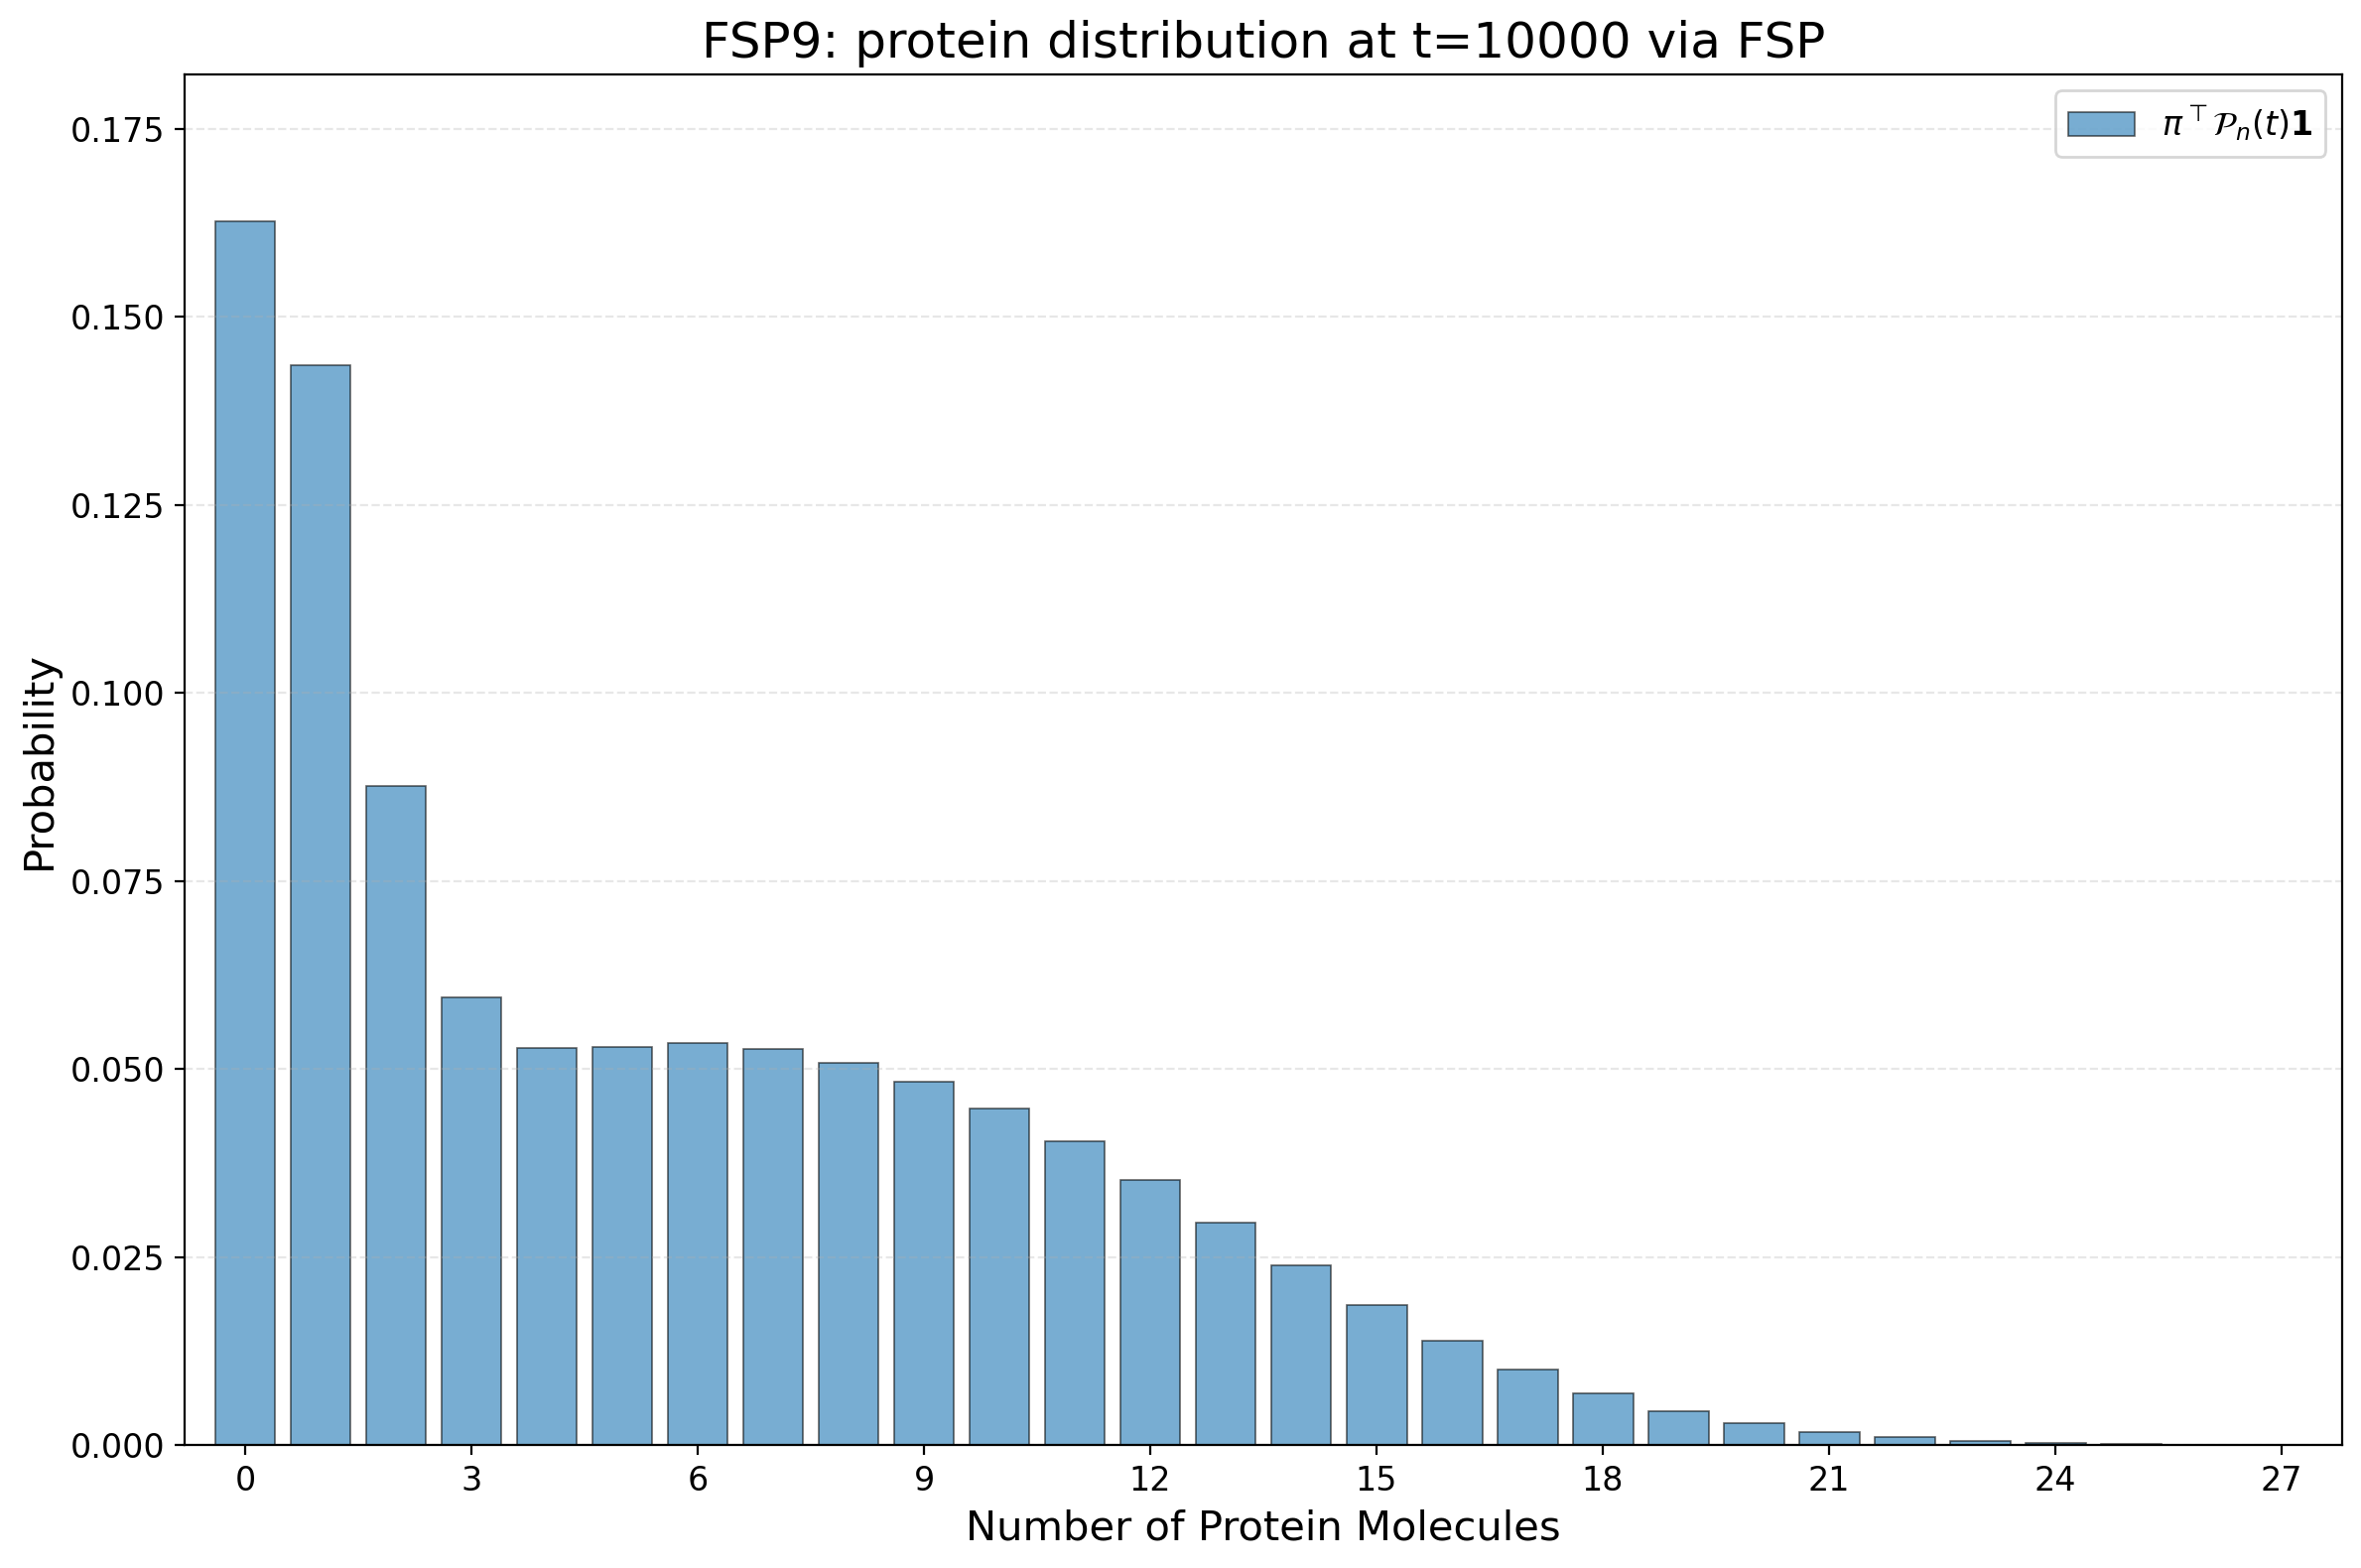

Example     Pmax         Sink         Mean     Variance    Seconds
------------------------------------------------------------------
FSP1          80    7.079e-38     6.995885     9.023796     0.3274
FSP2          80    1.859e-26     8.854167    12.895194     0.3440
FSP3          80    1.151e-30     0.816327     3.298626     0.1839
FSP4          40    9.734e-14     1.632653     2.695846     0.0889
FSP5          40    1.228e-13     2.779605     7.515463     0.0887
FSP6          80    5.476e-27     7.537362    32.808046     4.7745
FSP7          80    6.524e-33     5.529086    33.237373     4.7341
FSP8          80    7.063e-27     3.728395    23.023366    19.5683
FSP9          80    2.386e-26     5.580247    25.752392    66.9439


In [6]:
EXAMPLES_TO_RUN = list(EXPERIMENTS)
# EXAMPLES_TO_RUN = ["FSP1"]

# All keyword arguments below are shared by every selected experiment.
results = run_many(
    EXAMPLES_TO_RUN,

    # Accept the projection once less than 1e-12 probability has entered the
    # truncation sink.
    tol=1e-12,

    # Begin with protein counts 0 through 20.
    pmax_init=20,

    # Prevent adaptive growth beyond this hard safety limit.
    pmax_max=5000,

    # Double the cutoff after each unsuccessful projection.
    growth_factor=2.0,

    # Place all initial probability at zero proteins, distributed across different metastable states
    # according to the stationary gene state distribution.
    initial_protein=0,

    # Store each accepted marginal PMF in this directory.
    output_dir="fsp_results",

    # Save numerical output, display a plot, and print progress information.
    save=True,
    plot=True,
    verbose=True,
)

# Compare all completed experiments in one compact table.
print_batch_summary(results)
